# Generalizability: prediction performance across diverse datasets 

Here we assess the generalizability of our toolbox using open datasets across different experimental conditions, including varied imaging sites, scanner types, and visual stimuli protocols used for retinotopic mapping. 
To do so, we focus on qualitative assessment using hexbin plots and quantitative assessment with correlation scores. For each dataset, we start by vectorizing both the empirical and the predicted maps and then we filter out vertices for which the empirically devired pRF parameters have low variance explained. We then concatenate these vectors across participants, and generate hexbin plot for each topographic map. The closer the data lies along the diagonal, the closer the predicted parameters are to the empirical ones. In this notebook, you will find code to perform the following steps:
1. Data download and formatting (for all datasets available via OpenNeuro);
2. Map visualization;
3. Hexbin plots generation;
4. Performance quantification;


## Import libraries and functions

In [1]:
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import os
import astropy.units as u
import numpy as np
import nibabel as nib
import subprocess

sys.path.append('./../')

from functions.evaluation import *
from functions.datasets import *
from astropy.stats import circcorrcoef
from functions.visualization import retinotopic_map_plot
from deepRetinotopy_TheToolbox.utils.rois import ROI_WangParcelsPlusFovea as roi
from ipywidgets import interact, Dropdown

## General configurations

In [2]:
# Define retinotopic maps
retinotopic_maps = ['polarAngle', 'eccentricity', 'pRFsize']

# Define dataset paths
datasets = {'nyu':  '../datasets/openneuro_deepRetinotopy/ds003787/derivatives/freesurfer/', 
            'stanford': '../datasets/openneuro_deepRetinotopy/ds004440/derivatives/freesurfer/',
            'chn': '../datasets/openneuro_deepRetinotopy/ds004698/derivatives/freesurfer/',
            'hcp': '../datasets/hcp_training/freesurfer/',
            'kiwi': '../datasets/RetinotopyKiwi/'}

output_dir = {'nyu': '../datasets/deepretinotopy_1.0.19_output/nyu/',
              'stanford': '../datasets/deepretinotopy_1.0.19_output/stanford/',
              'hcp': '../datasets/hcp_training/freesurfer/',
              'chn': '../datasets/deepretinotopy_1.0.19_output/chn/',
              'kiwi': '../datasets/deepretinotopy_1.0.19_output/kiwi/'}

# Config variance explained threshold
variance_explained_threshold = {'nyu': 0.1,
                                'stanford': 0.1,
                                'hcp': 10,
                                'chn': 0.1,
                                'kiwi': 0.1}

# Experiment with different datasets
experiment_datasets = {'nyu': None,
                       'stanford': None,
                       'hcp': None,
                       'chn': 'all',
                       'kiwi': 'CanHrf'}

## 1. Data download and formatting

In [4]:
# Function for running the download and processing script of each dataset
DATASET_SCRIPTS = {'nyu': 'nyu_data.sh',
                   'stanford': 'stanford_data.sh',
                   'chn': 'chn_data.sh',
                   'kiwi': 'newzealand_data.sh'}

def run_bash_script(dataset, dataset_path=None, hcp_templates_path=None, path_to_validation_repository=None, output_path=None):
    """
    Run the download and processing script of a dataset in a detached screen session.
    Args:
        dataset (str): The name of the dataset ('nyu', 'stanford', 'chn' or 'kiwi').
        dataset_path (str, optional): Path to where the dataset should be stored.
        hcp_templates_path (str, optional): Path to HCP templates.
        path_to_validation_repository (str, optional): Path to the validation repository.
        output_path (str, optional): Path to the output directory.
    Returns:
        session (str): Name of the screen session, or None if the dataset has no script.
    """
    if dataset not in DATASET_SCRIPTS:
        print(f"No download script for '{dataset}'; choose from {list(DATASET_SCRIPTS)}. Nothing was started.")
        return None
    os.makedirs(dataset_path, exist_ok = True)
    os.makedirs(output_path, exist_ok = True)

    # Arguments are passed as a list, so paths are not split by the shell
    session = f'{dataset}-download'
    command = ['screen', '-S', session, '-dm',
               'bash', f'./../scripts/{DATASET_SCRIPTS[dataset]}',
               '-d', dataset_path,
               '-t', hcp_templates_path,
               '-r', path_to_validation_repository,
               '-o', output_path]
    # check = True raises if screen itself fails to start; the script runs detached, so its own
    # exit status is not reported here (attach with: screen -r <session>)
    subprocess.run(command, check = True)
    # Answer the confirmation prompt of the script
    subprocess.run(['screen', '-S', session, '-X', 'stuff', 'y\n'], check = True)
    print(f"Started {DATASET_SCRIPTS[dataset]} in screen session '{session}'")
    return session


In [ ]:
# for dataset in list(datasets.keys()):
for dataset in ['chn', 'stanford', 'nyu', 'kiwi']:
    if dataset != 'hcp':
        run_bash_script(dataset, 
                        dataset_path='../datasets/',
                        hcp_templates_path='../datasets/templates_2016',
                        path_to_validation_repository='..',
                        output_path=output_dir[dataset])
    else:
        continue

Started chn_data.sh in screen session 'chn-download'
Started stanford_data.sh in screen session 'stanford-download'
Started nyu_data.sh in screen session 'nyu-download'


## 2. Visualizing topographic maps

In [3]:
import glob
dataset_name = 'nyu'
path_to_freesurfer = output_dir[dataset_name]
subject_id = os.listdir(path_to_freesurfer)

for file in glob.glob(os.path.join(path_to_freesurfer, '*.log')) + \
            glob.glob(os.path.join(path_to_freesurfer, '*.txt')) + \
            glob.glob(os.path.join(path_to_freesurfer, 'processed*')) + \
            glob.glob(os.path.join(path_to_freesurfer, '*.m')):
    subject = file.split('/')[-1]
    subject_id.remove(subject)
subject_id.sort()

prediction = Dropdown(options = ['empirical',
                                 'model'])
retinotopic_map = Dropdown(options=['polarAngle', 'eccentricity', 'pRFsize'])
binarize = Dropdown(options = [False, True])
hemisphere = Dropdown(options = ['lh', 'rh'])

@interact(subject_id=subject_id, prediction = prediction, 
          binarize = binarize, retinotopic_map = retinotopic_map,
          hemisphere = hemisphere)
def plot1(subject_id,prediction, binarize, retinotopic_map, hemisphere):
    return retinotopic_map_plot(subject_id, path_to_freesurfer, '../datasets/templates_2016/',
                                 prediction = prediction, binarize = binarize,
                                 retinotopic_map = retinotopic_map, 
                                 hemisphere = hemisphere, 
                                 dataset = dataset_name,
                                 experiment = experiment_datasets[dataset_name])

interactive(children=(Dropdown(description='subject_id', options=('sub-wlsubj001', 'sub-wlsubj004', 'sub-wlsub…

## 3. Hexbin plots generation

Here we generate the hexbin plots shown in Figure 3 of the manuscript. To visualize and generate the plots for different datasets, you only need to change the dataset_name variable.

Region of interest: earlyvisualcortex
Threshold: 0.1
Saving plot to ../output_revision/model_evaluation/chn/PredictedVsEmpirical_polarAngle_all_both_0.1_earlyvisualcortex_hexbin.png and ../output_revision/model_evaluation/chn/PredictedVsEmpirical_polarAngle_all_both_0.1_earlyvisualcortex_hexbin.pdf


<Figure size 1000x1000 with 0 Axes>

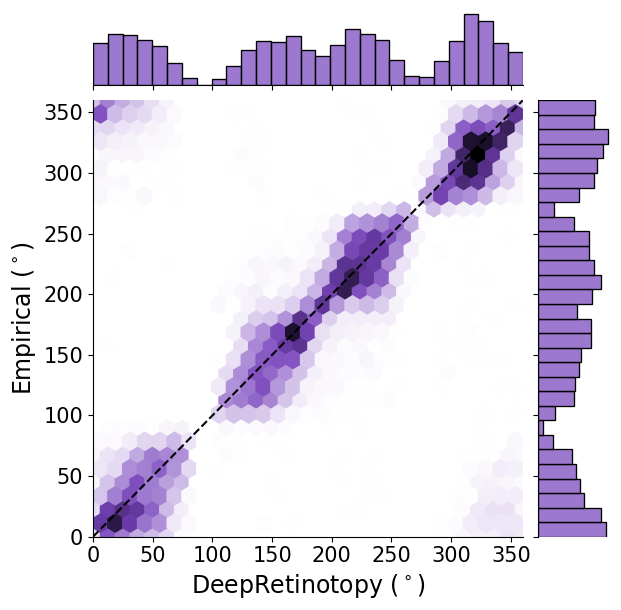

Threshold: 0.1
Saving plot to ../output_revision/model_evaluation/chn/PredictedVsEmpirical_eccentricity_all_both_0.1_earlyvisualcortex_hexbin.png and ../output_revision/model_evaluation/chn/PredictedVsEmpirical_eccentricity_all_both_0.1_earlyvisualcortex_hexbin.pdf


<Figure size 1000x1000 with 0 Axes>

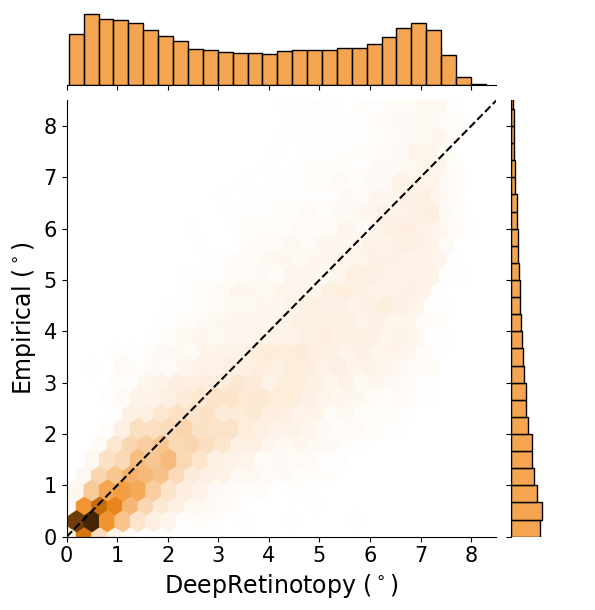

Threshold: 0.1
Saving plot to ../output_revision/model_evaluation/chn/PredictedVsEmpirical_pRFsize_all_both_0.1_earlyvisualcortex_hexbin.png and ../output_revision/model_evaluation/chn/PredictedVsEmpirical_pRFsize_all_both_0.1_earlyvisualcortex_hexbin.pdf


<Figure size 1000x1000 with 0 Axes>

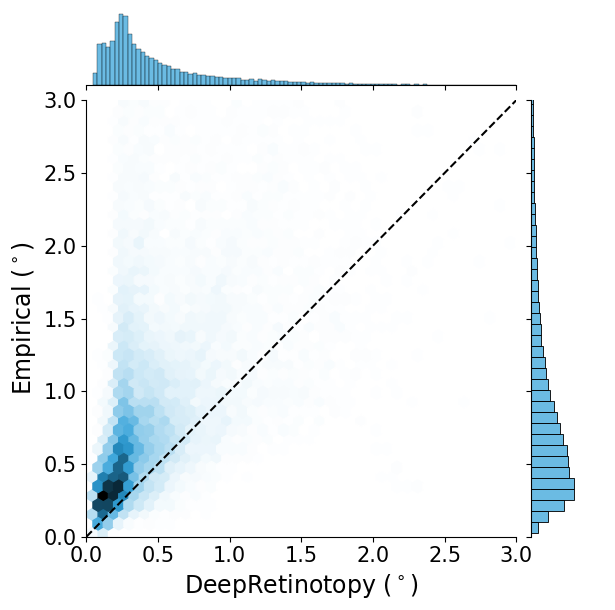

Region of interest: earlyvisualcortex
Threshold: 0.1
Saving plot to ../output_revision/model_evaluation/stanford/PredictedVsEmpirical_polarAngle_both_0.1_earlyvisualcortex_hexbin.png and ../output_revision/model_evaluation/stanford/PredictedVsEmpirical_polarAngle_both_0.1_earlyvisualcortex_hexbin.pdf


<Figure size 1000x1000 with 0 Axes>

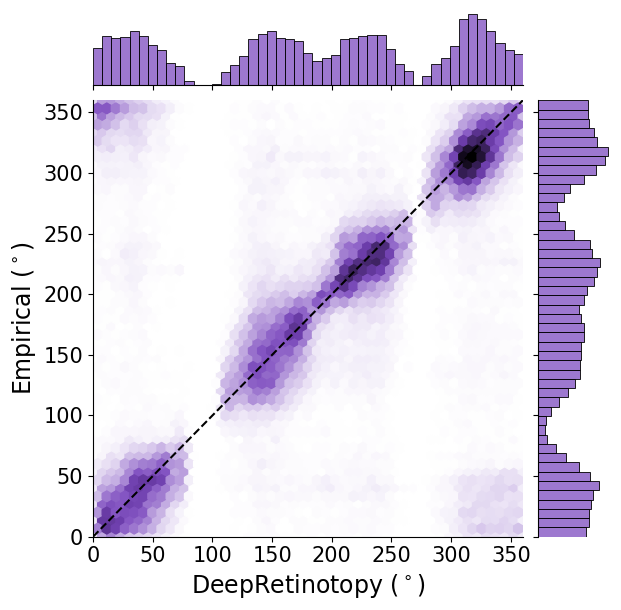

Threshold: 0.1
Saving plot to ../output_revision/model_evaluation/stanford/PredictedVsEmpirical_eccentricity_both_0.1_earlyvisualcortex_hexbin.png and ../output_revision/model_evaluation/stanford/PredictedVsEmpirical_eccentricity_both_0.1_earlyvisualcortex_hexbin.pdf


<Figure size 1000x1000 with 0 Axes>

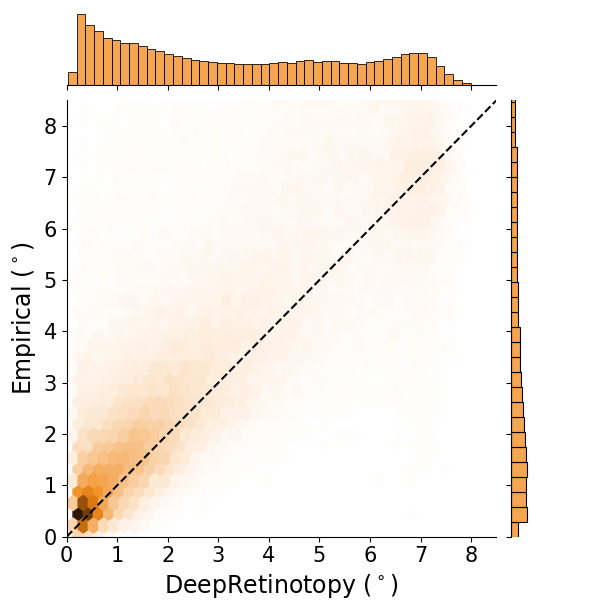

Threshold: 0.1
Saving plot to ../output_revision/model_evaluation/stanford/PredictedVsEmpirical_pRFsize_both_0.1_earlyvisualcortex_hexbin.png and ../output_revision/model_evaluation/stanford/PredictedVsEmpirical_pRFsize_both_0.1_earlyvisualcortex_hexbin.pdf


<Figure size 1000x1000 with 0 Axes>

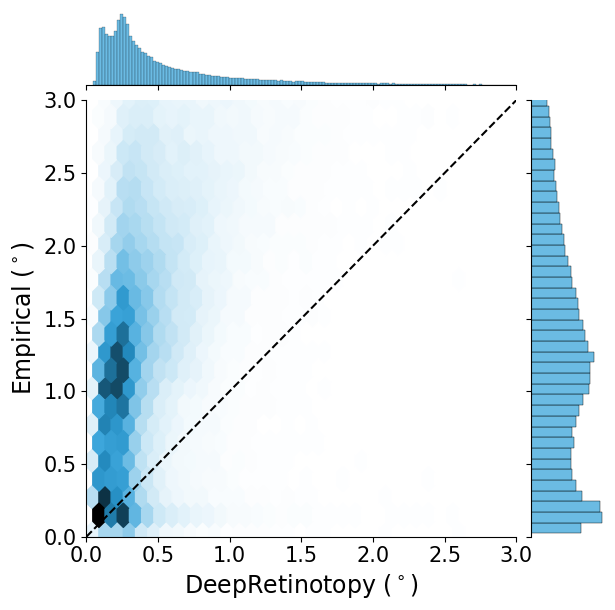

Region of interest: earlyvisualcortex
Threshold: 0.1
Saving plot to ../output_revision/model_evaluation/nyu/PredictedVsEmpirical_polarAngle_both_0.1_earlyvisualcortex_hexbin.png and ../output_revision/model_evaluation/nyu/PredictedVsEmpirical_polarAngle_both_0.1_earlyvisualcortex_hexbin.pdf


<Figure size 1000x1000 with 0 Axes>

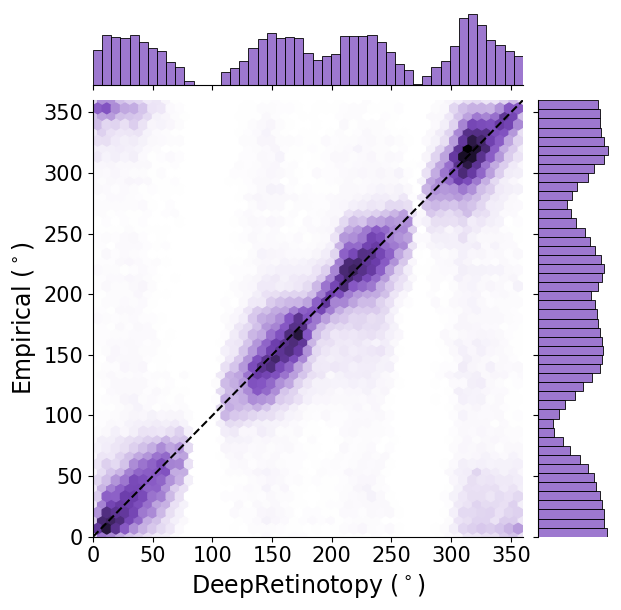

Threshold: 0.1
Saving plot to ../output_revision/model_evaluation/nyu/PredictedVsEmpirical_eccentricity_both_0.1_earlyvisualcortex_hexbin.png and ../output_revision/model_evaluation/nyu/PredictedVsEmpirical_eccentricity_both_0.1_earlyvisualcortex_hexbin.pdf


<Figure size 1000x1000 with 0 Axes>

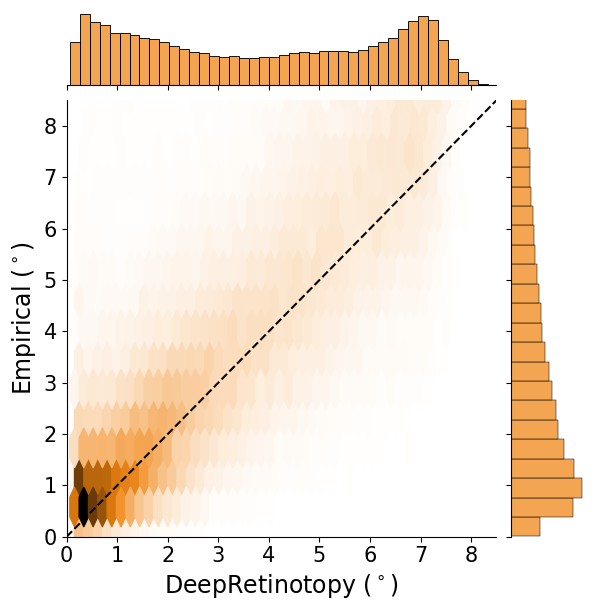

Threshold: 0.1
Saving plot to ../output_revision/model_evaluation/nyu/PredictedVsEmpirical_pRFsize_both_0.1_earlyvisualcortex_hexbin.png and ../output_revision/model_evaluation/nyu/PredictedVsEmpirical_pRFsize_both_0.1_earlyvisualcortex_hexbin.pdf


<Figure size 1000x1000 with 0 Axes>

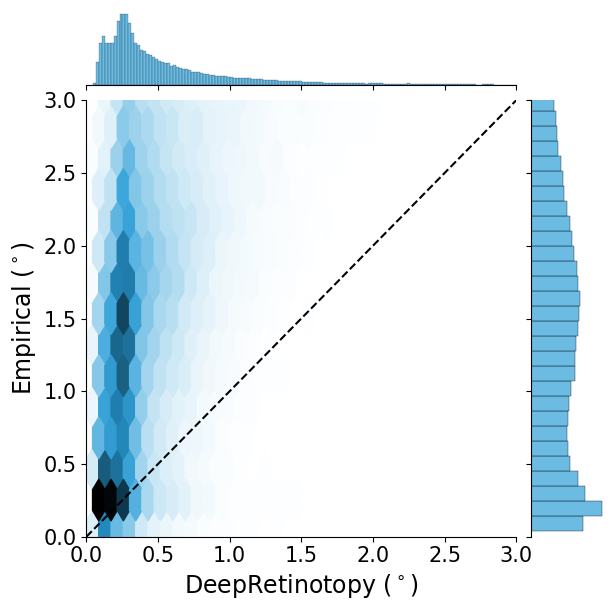

Region of interest: earlyvisualcortex
Threshold: 0.1
Saving plot to ../output_revision/model_evaluation/kiwi/PredictedVsEmpirical_polarAngle_CanHrf_both_0.1_earlyvisualcortex_hexbin.png and ../output_revision/model_evaluation/kiwi/PredictedVsEmpirical_polarAngle_CanHrf_both_0.1_earlyvisualcortex_hexbin.pdf


<Figure size 1000x1000 with 0 Axes>

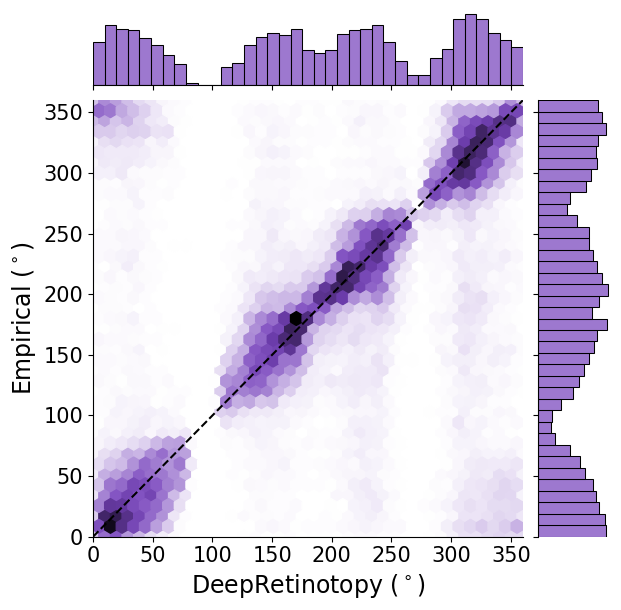

Threshold: 0.1
Saving plot to ../output_revision/model_evaluation/kiwi/PredictedVsEmpirical_eccentricity_CanHrf_both_0.1_earlyvisualcortex_hexbin.png and ../output_revision/model_evaluation/kiwi/PredictedVsEmpirical_eccentricity_CanHrf_both_0.1_earlyvisualcortex_hexbin.pdf


<Figure size 1000x1000 with 0 Axes>

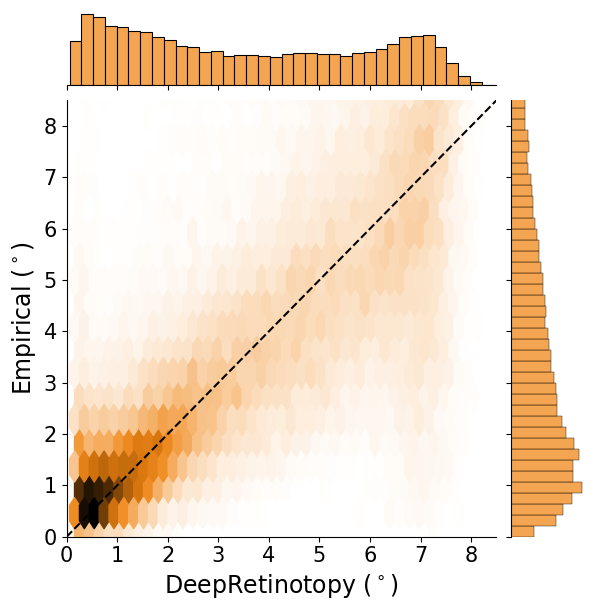

Threshold: 0.1
Saving plot to ../output_revision/model_evaluation/kiwi/PredictedVsEmpirical_pRFsize_CanHrf_both_0.1_earlyvisualcortex_hexbin.png and ../output_revision/model_evaluation/kiwi/PredictedVsEmpirical_pRFsize_CanHrf_both_0.1_earlyvisualcortex_hexbin.pdf


<Figure size 1000x1000 with 0 Axes>

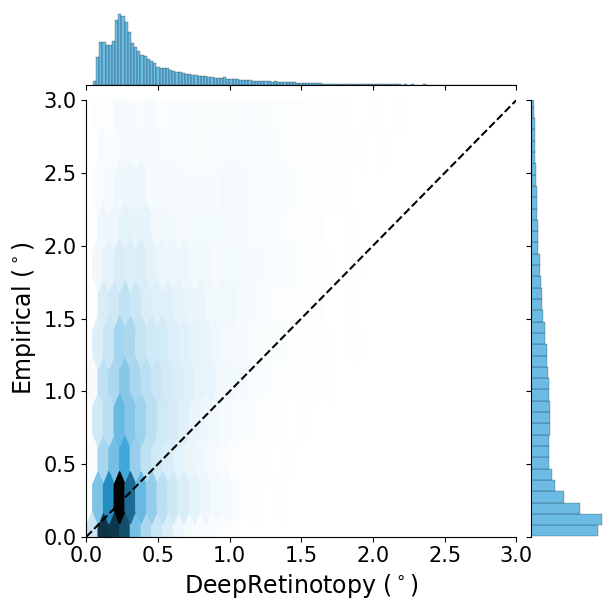

Region of interest: earlyvisualcortex
Threshold: 10
Saving plot to ../output_revision/model_evaluation/hcp/PredictedVsEmpirical_polarAngle_both_10_earlyvisualcortex_hexbin.png and ../output_revision/model_evaluation/hcp/PredictedVsEmpirical_polarAngle_both_10_earlyvisualcortex_hexbin.pdf


<Figure size 1000x1000 with 0 Axes>

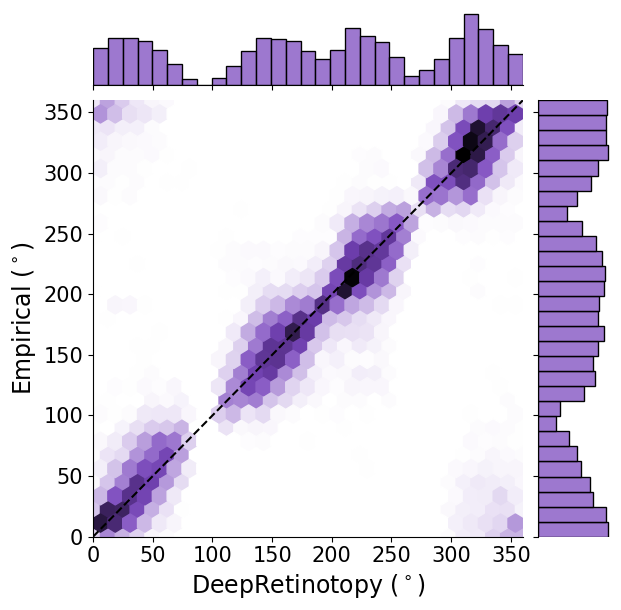

Threshold: 10
Saving plot to ../output_revision/model_evaluation/hcp/PredictedVsEmpirical_eccentricity_both_10_earlyvisualcortex_hexbin.png and ../output_revision/model_evaluation/hcp/PredictedVsEmpirical_eccentricity_both_10_earlyvisualcortex_hexbin.pdf


<Figure size 1000x1000 with 0 Axes>

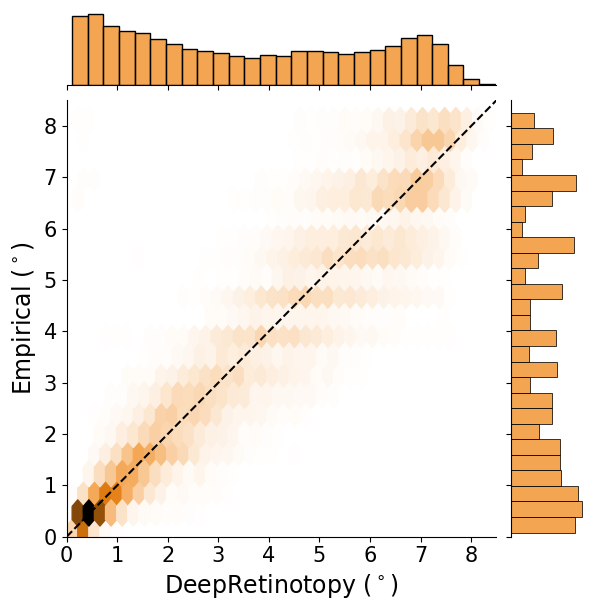

Threshold: 10
Saving plot to ../output_revision/model_evaluation/hcp/PredictedVsEmpirical_pRFsize_both_10_earlyvisualcortex_hexbin.png and ../output_revision/model_evaluation/hcp/PredictedVsEmpirical_pRFsize_both_10_earlyvisualcortex_hexbin.pdf


<Figure size 1000x1000 with 0 Axes>

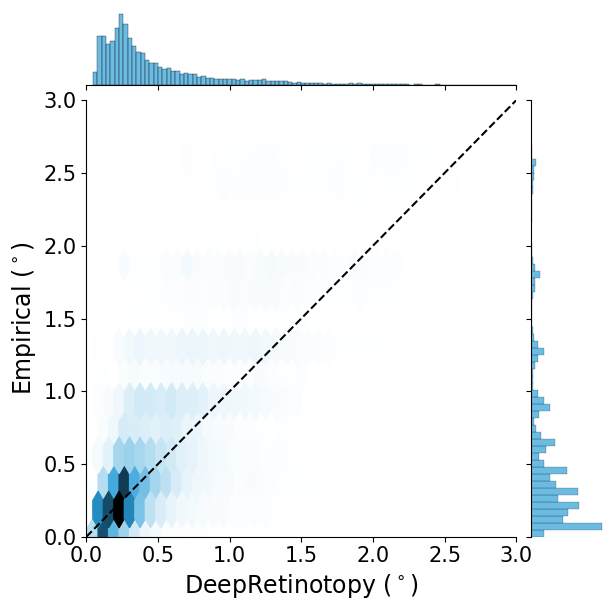

In [3]:
# Change the dataset name here:

for dataset_name in ['chn', 'stanford', 'nyu', 'kiwi', 'hcp']:
    # Configuration
    path = output_dir[dataset_name]
    retinotopic_maps = ['polarAngle', 'eccentricity', 'pRFsize']
    hemispheres='both'

    # Generate hexbin plots and correlation table
    threshold = variance_explained_threshold[dataset_name]
    corr_scores = predicted_vs_empirical(path, dataset_name, retinotopic_maps, 
                            hemispheres = hemispheres, 
                            threshold=threshold, 
                            experiment=experiment_datasets[dataset_name],
                            region_of_interest = 'earlyvisualcortex',
                            output_dir = '../output_revision/')
    base_path = f'../output_revision/model_evaluation/{dataset_name}/'
    if os.path.isdir(base_path) == False:
        os.mkdir(base_path)
    corr_scores.to_csv(f'{base_path}prediction_performance_{dataset_name}.csv', index=False)

## 4. Comparing deepretinotopy predictions against pRF parameters using different encoding models

Each dataset used to assess generalizability was fitted with a different encoding model, and encoding models differ in their assumptions and optimization, which leads to systematic differences between the estimated pRF parameters. DeepRetinotopy reproduces the distribution of its training data, which was fitted with analyzePRF (the HCP 7T retinotopy pipeline). To separate prediction error from encoding model differences, the NYU dataset was refitted with analyzePRF, and here we compare (1) the original NYU estimates against the analyzePRF estimates, and (2) the deepRetinotopy predictions against each of them, with the same hexbin plots and per-subject correlations as in Section 3.

In sum, we performed the following steps:
1. Resample the analyzePRF estimates from native space to the 32k_fs_LR space, as a new `prfanalyze` experiment next to `all`, `fixedbar` and `logbar`.
2. Define `map_vs_map`, the counterpart of `predicted_vs_empirical` in which either map can be the deepRetinotopy prediction or an empirical map from a given experiment.
3. Generate the plots and correlation tables for the three comparisons.
4. Summarise the deviations as a mean error per subject in early visual cortex, as bars: the prediction error against each encoding model, with the disagreement between the two encoding models as a reference band.


In [ ]:
%%bash
ml connectomeworkbench/1.5.0
ml deepretinotopy/1.0.19

# Resample the analyzePRF estimates (native space) to the 32k_fs_LR space. Same steps as in the dataset
# scripts: x0, y0, pRF size and variance explained are resampled, and polar angle and eccentricity are
# reconstructed from the resampled x0/y0, so that the 0/360 wrap of the angle is never interpolated.
# The analyzePRF x0/y0 are in the natural convention for both datasets (x right, y up), so unlike the
# original NYU estimates in scripts/nyu_data.sh, y is not flipped here.
repo=/LOCAL/ribeiro/deepRetinotopy_validation
dirHCP=$repo/datasets/templates_2016
experiment=prfanalyze

# NYU: the loader of this dataset has no experiment tag, so the maps go to a 'prfanalyze' folder next
#     to 'surf' and are read with RetinotopyData(..., empirical_dir = 'prfanalyze'). Subjects without an
#     analyzePRF fit are skipped.
nativeDir=$repo/datasets/hcpgrid_nyu_prfanalyze/ds003787
outputDir=$repo/datasets/deepretinotopy_1.0.19_output/nyu
cd $outputDir
for sub in sub-*; do
    if [ ! -f $nativeDir/$sub/gifti/"$sub"_task-prf_hemi-L_space-fsnative_desc-analyzePRF_x0.func.gii ]; then
        echo "$sub: no analyzePRF fit, skipped"
        continue
    fi
    surfDir=$outputDir/$sub/surf
    mapDir=$outputDir/$sub/$experiment
    mkdir -p $mapDir
    for hemisphere in lh rh; do
        if [ "$hemisphere" == "lh" ]; then hemi=L; else hemi=R; fi
        for metric in x0 y0 sigma vexpl; do
            if [ $metric == "sigma" ]; then
                metric_new="pRFsize"
            elif [ $metric == "vexpl" ]; then
                metric_new="variance_explained"
            else
                metric_new=$metric
            fi
            wb_command -metric-resample $nativeDir/$sub/gifti/"$sub"_task-prf_hemi-"$hemi"_space-fsnative_desc-analyzePRF_"$metric".func.gii \
                $surfDir/"$hemisphere".sphere.reg.surf.gii $dirHCP/fs_LR-deformed_to-fsaverage."$hemi".sphere.32k_fs_LR.surf.gii \
                ADAP_BARY_AREA $mapDir/"$sub".fs_empirical_"$metric_new"_"$hemisphere".func.gii \
                -area-surfs $surfDir/"$hemisphere".midthickness.surf.gii $surfDir/"$sub"."$hemisphere".midthickness.32k_fs_LR.surf.gii
        done
        reconstruct_coords_native.py \
            --x $mapDir/"$sub".fs_empirical_x0_"$hemisphere".func.gii \
            --y $mapDir/"$sub".fs_empirical_y0_"$hemisphere".func.gii \
            --polarangle $mapDir/"$sub".fs_empirical_polarAngle_"$hemisphere".func.gii \
            --eccentricity $mapDir/"$sub".fs_empirical_eccentricity_"$hemisphere".func.gii
    done
    echo "$sub done"
done


Reconstructed polarAngle + eccentricity from x/y (32492 vertices)
Reconstructed polarAngle + eccentricity from x/y (32492 vertices)
sub-wlsubj001 done
Reconstructed polarAngle + eccentricity from x/y (32492 vertices)
Reconstructed polarAngle + eccentricity from x/y (32492 vertices)
sub-wlsubj004 done
Reconstructed polarAngle + eccentricity from x/y (32492 vertices)
Reconstructed polarAngle + eccentricity from x/y (32492 vertices)
sub-wlsubj006 done
Reconstructed polarAngle + eccentricity from x/y (32492 vertices)
Reconstructed polarAngle + eccentricity from x/y (32492 vertices)
sub-wlsubj007 done
Reconstructed polarAngle + eccentricity from x/y (32492 vertices)
Reconstructed polarAngle + eccentricity from x/y (32492 vertices)
sub-wlsubj014 done
Reconstructed polarAngle + eccentricity from x/y (32492 vertices)
Reconstructed polarAngle + eccentricity from x/y (32492 vertices)
sub-wlsubj019 done
Reconstructed polarAngle + eccentricity from x/y (32492 vertices)
Reconstructed polarAngle + e

In [3]:
from functions.evaluation import roi, roi_earlyvisualcortex, roi_parcel, create_mask, return_list_of_subs, remove_outliers

# A map source is ('predicted', None) for the deepRetinotopy prediction, ('empirical', None) for the
# empirical map released with the dataset (its own encoding model), or ('empirical', 'prfanalyze') for the
# refit with analyzePRF. For CHN and Kiwi any other experiment name ('fixedbar', 'logbar', ...) works too.
MAP_SOURCE_LABELS = {('predicted', None): 'DeepRetinotopy',
                     ('empirical', None): 'Empirical (original fit)',
                     ('empirical', 'prfanalyze'): 'Empirical (analyzePRF)'}
MAP_SOURCE_FILE_NAMES = {('predicted', None): 'predicted',
                         ('empirical', None): 'empirical-original',
                         ('empirical', 'prfanalyze'): 'empirical-prfanalyze'}
MAP_COLORS = {'polarAngle': '#7d4bbfff', 'eccentricity': '#f08717ff', 'pRFsize': '#39a4daff'}
MAP_LIMITS = {'polarAngle': 360, 'eccentricity': 8.5, 'pRFsize': 3}
MAP_TITLES = {'polarAngle': 'Polar Angle', 'eccentricity': 'Eccentricity', 'pRFsize': 'pRF size'}


def load_map_source(source, path, dataset_name, subject_id, hemisphere, retinotopic_map, mask):
    """Load one map of one subject, masked to the region of interest, with the variance explained that
    qualifies its vertices.

    Args:
        source (tuple): Map source, ('predicted', None), ('empirical', None) or ('empirical', experiment).
        path (str): Path to the directory holding the subjects (predicted maps in <subject>/deepRetinotopy,
            empirical maps in <subject>/surf, or in <subject>/<experiment> for datasets without experiment tag).
        dataset_name (str): Name of the dataset ('chn', 'kiwi', 'nyu', 'stanford' or 'hcp').
        subject_id (str): Subject ID.
        hemisphere (str): Hemisphere ('lh' or 'rh').
        retinotopic_map (str): Retinotopic map ('polarAngle', 'eccentricity' or 'pRFsize').
        mask (numpy array): Boolean mask of the region of interest (32492,).

    Returns:
        values (numpy array): Map values within the mask.
        variance_explained (numpy array): Variance explained within the mask, or None for a predicted map,
            which has no variance explained of its own.
    """
    map_type, experiment = source
    empirical_dir = 'surf' if experiment is None else experiment
    data = RetinotopyData(path, subject_id, hemisphere, retinotopic_map, empirical_dir = empirical_dir)
    data.apply_mask_to_maps(mask)
    # Normalise legacy predictions to the natural polar angle convention (no-op for the visualCoord models)
    data.normalize_polarangle_convention()
    if map_type == 'predicted':
        return data.predicted_map.flatten(), None
    return data.empirical_map.flatten(), data.variance_explained.flatten()


def map_vs_map(path, dataset_name, map_x, map_y, retinotopic_maps, hemispheres,
               threshold = None, region_of_interest = 'earlyvisualcortex', plot_type = 'hexbin',
               output_dir = '../output_revision/', excluded_subjects = []):
    """Generate hexbin plots and per-subject correlations between two maps, as predicted_vs_empirical does
    for the deepRetinotopy prediction and the empirical map, but with either map being the prediction or an
    empirical map from any experiment (encoding model).

    Vertices are kept when both maps are finite and non-zero (unfitted vertices are 0 in the original CHN
    maps and NaN in the analyzePRF maps) and when the variance explained of the ORIGINAL empirical map of
    the dataset is above the threshold, whatever the two maps compared, so that every comparison is made on
    the same vertices.

    Args:
        path (str): Path to the directory holding the subjects (predicted maps in <subject>/deepRetinotopy,
            empirical maps in <subject>/surf).
        dataset_name (str): Name of the dataset ('chn', 'kiwi', 'nyu', 'stanford' or 'hcp').
        map_x (tuple): Map source on the x axis, ('predicted', None), ('empirical', None) or ('empirical', experiment).
        map_y (tuple): Map source on the y axis, same format.
        retinotopic_maps (list): List of retinotopic maps ('polarAngle', 'eccentricity' or 'pRFsize').
        hemispheres (str): Hemisphere ('lh', 'rh' or 'both').
        threshold (float): Threshold for the variance explained of the original empirical map, None for no threshold.
        region_of_interest (str): Region of interest ('all', 'earlyvisualcortex', 'V1', 'V2' or 'V3').
        plot_type (str): Type of plot ('hexbin' or 'kde').
        output_dir (str): Output directory; plots are saved under <output_dir>model_evaluation/<dataset_name>/.
        excluded_subjects (list): Subject IDs left out of the comparison (for example, no analyzePRF fit).

    Returns:
        correlation_scores_table (pandas DataFrame): One row per subject, hemisphere and map, with columns
            'scores', 'hemisphere', 'retinotopic_map', 'map_x' and 'map_y'.
    """
    if hemispheres == 'both':
        hemispheres = ['lh', 'rh']
    else:
        hemispheres = [hemispheres]

    # Region of interest
    print('Region of interest: ' + region_of_interest)
    final_mask_L_ROI, final_mask_R_ROI, index_L_mask, index_R_mask = roi(['ROI'])
    final_mask_L, final_mask_R, index_L_mask, index_R_mask = roi_earlyvisualcortex(['ROI'])
    if region_of_interest == 'V1':
        final_mask_L, final_mask_R, index_L_mask, index_R_mask = roi_parcel(['V1v', 'V1d'])
    elif region_of_interest == 'V2':
        final_mask_L, final_mask_R, index_L_mask, index_R_mask = roi_parcel(['V2v', 'V2d'])
    elif region_of_interest == 'V3':
        final_mask_L, final_mask_R, index_L_mask, index_R_mask = roi_parcel(['V3v', 'V3d'])

    save_path = f'{output_dir}model_evaluation/{dataset_name}/encoding_model_comparisons/'
    os.makedirs(save_path, exist_ok = True)
    list_of_sub_ids = [subject_id for subject_id in return_list_of_subs(path, dataset_name) if subject_id not in excluded_subjects]
    if len(excluded_subjects) > 0:
        print(f'Excluded subjects: {excluded_subjects}')
    label_x = MAP_SOURCE_LABELS.get(map_x, f'Empirical ({map_x[1]})')
    label_y = MAP_SOURCE_LABELS.get(map_y, f'Empirical ({map_y[1]})')
    name_x = MAP_SOURCE_FILE_NAMES.get(map_x, f'empirical-{map_x[1]}')
    name_y = MAP_SOURCE_FILE_NAMES.get(map_y, f'empirical-{map_y[1]}')
    print(f'Comparing {label_x} (x) against {label_y} (y) in {dataset_name}, {len(list_of_sub_ids)} subjects')

    rows = []
    for retinotopic_map in retinotopic_maps:
        values_x, values_y = [], []
        for hemisphere in hemispheres:
            ROI_masked, mask = create_mask(final_mask_L_ROI, final_mask_R_ROI, final_mask_L, final_mask_R, hemisphere)
            mask_final = ROI_masked if region_of_interest == 'all' else mask
            for subject_id in list_of_sub_ids:
                x, _ = load_map_source(map_x, path, dataset_name, subject_id, hemisphere, retinotopic_map, mask_final)
                y, _ = load_map_source(map_y, path, dataset_name, subject_id, hemisphere, retinotopic_map, mask_final)
                # The threshold always comes from the original empirical map, so that every comparison uses
                # the same vertices
                _, variance_explained = load_map_source(('empirical', None), path, dataset_name, subject_id, hemisphere, retinotopic_map, mask_final)

                # Keep vertices fitted in both maps and above threshold
                keep = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
                if threshold is not None:
                    keep = keep & (np.nan_to_num(variance_explained) > threshold)
                x, y = x[keep], y[keep]
                if retinotopic_map == 'eccentricity' and dataset_name == 'chn':
                    x, y = np.clip(x, 0, 9), np.clip(y, 0, 9)

                # Correlation per subject and hemisphere
                if retinotopic_map == 'polarAngle':
                    corr = circcorrcoef(x * u.deg, y * u.deg)
                else:
                    corr = scipy.stats.pearsonr(x, y)[0]
                rows.append({'scores': float(corr), 'hemisphere': hemisphere, 'retinotopic_map': retinotopic_map,
                             'map_x': name_x, 'map_y': name_y})
                values_x += list(x)
                values_y += list(y)
        values_x, values_y = remove_outliers(values_x, values_y, retinotopic_map, dataset_name)

        # Plot
        data = pd.DataFrame({label_x: values_x, label_y: values_y})
        fig = plt.figure(figsize = (10, 10))
        # Map colours for comparisons involving the prediction, grey when two empirical maps are compared
        if map_x[0] == 'empirical' and map_y[0] == 'empirical':
            color, cmap = '#999999ff', 'Greys'
        else:
            color, cmap = MAP_COLORS[retinotopic_map], 'Blues'
        if plot_type == 'kde':
            sns.kdeplot(x = data[label_x], y = data[label_y], cmap = cmap, fill = True, cbar = True)
        else:
            sns.jointplot(x = data[label_x], y = data[label_y], color = color, kind = 'hex')
        plt.xlabel(label_x + ' ($^\\circ$)', fontsize = 17)
        plt.ylabel(label_y + ' ($^\\circ$)', fontsize = 17)
        plt.yticks(fontsize = 15)
        plt.xticks(fontsize = 15)
        limit = MAP_LIMITS[retinotopic_map]
        plt.plot([0, limit], [0, limit], 'k--')
        plt.xlim(0, limit)
        plt.ylim(0, limit)
        if len(hemispheres) > 1:
            fig.suptitle(MAP_TITLES[retinotopic_map])
        else:
            fig.suptitle(MAP_TITLES[retinotopic_map] + ' - ' + hemispheres[0])

        # Save
        hemisphere_name = 'both' if len(hemispheres) > 1 else hemispheres[0]
        threshold_str = f'_{threshold}' if threshold is not None else ''
        file_name = f'{save_path}MapVsMap_{retinotopic_map}_{name_x}_vs_{name_y}_{hemisphere_name}{threshold_str}_{region_of_interest}_{plot_type}'
        plt.savefig(f'{file_name}.png')
        plt.savefig(f'{file_name}.pdf')
        print(f'Saving plot to {file_name}.png and {file_name}.pdf')
        plt.show()
    return pd.DataFrame(rows)


Region of interest: earlyvisualcortex
Excluded subjects: ['sub-wlsubj056']
Comparing Empirical (analyzePRF) (x) against Empirical (original fit) (y) in nyu, 42 subjects
Saving plot to ../output_revision/model_evaluation/nyu/encoding_model_comparisons/MapVsMap_polarAngle_empirical-prfanalyze_vs_empirical-original_both_0.1_earlyvisualcortex_hexbin.png and ../output_revision/model_evaluation/nyu/encoding_model_comparisons/MapVsMap_polarAngle_empirical-prfanalyze_vs_empirical-original_both_0.1_earlyvisualcortex_hexbin.pdf


<Figure size 1000x1000 with 0 Axes>

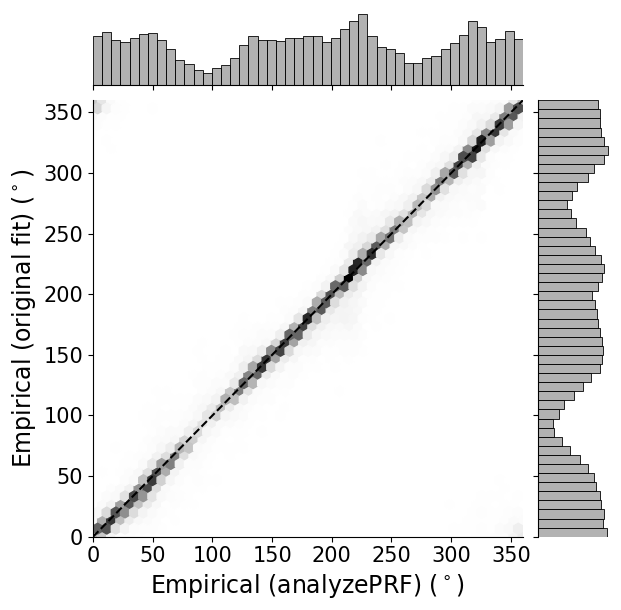

Saving plot to ../output_revision/model_evaluation/nyu/encoding_model_comparisons/MapVsMap_eccentricity_empirical-prfanalyze_vs_empirical-original_both_0.1_earlyvisualcortex_hexbin.png and ../output_revision/model_evaluation/nyu/encoding_model_comparisons/MapVsMap_eccentricity_empirical-prfanalyze_vs_empirical-original_both_0.1_earlyvisualcortex_hexbin.pdf


<Figure size 1000x1000 with 0 Axes>

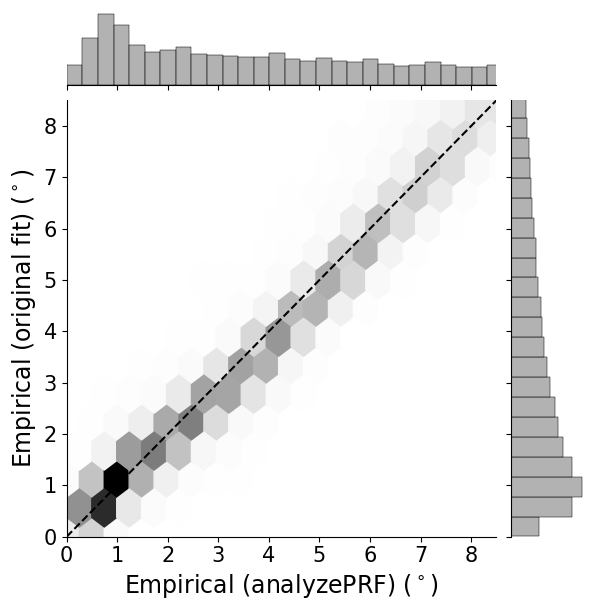

Saving plot to ../output_revision/model_evaluation/nyu/encoding_model_comparisons/MapVsMap_pRFsize_empirical-prfanalyze_vs_empirical-original_both_0.1_earlyvisualcortex_hexbin.png and ../output_revision/model_evaluation/nyu/encoding_model_comparisons/MapVsMap_pRFsize_empirical-prfanalyze_vs_empirical-original_both_0.1_earlyvisualcortex_hexbin.pdf


<Figure size 1000x1000 with 0 Axes>

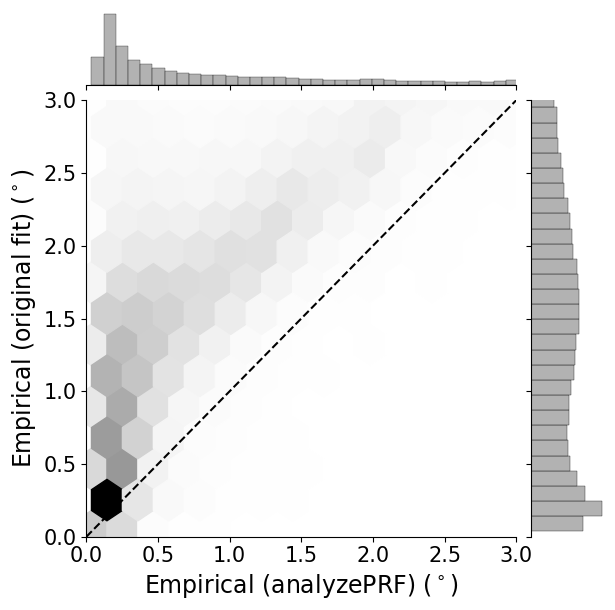

Region of interest: earlyvisualcortex
Excluded subjects: ['sub-wlsubj056']
Comparing DeepRetinotopy (x) against Empirical (original fit) (y) in nyu, 42 subjects
Saving plot to ../output_revision/model_evaluation/nyu/encoding_model_comparisons/MapVsMap_polarAngle_predicted_vs_empirical-original_both_0.1_earlyvisualcortex_hexbin.png and ../output_revision/model_evaluation/nyu/encoding_model_comparisons/MapVsMap_polarAngle_predicted_vs_empirical-original_both_0.1_earlyvisualcortex_hexbin.pdf


<Figure size 1000x1000 with 0 Axes>

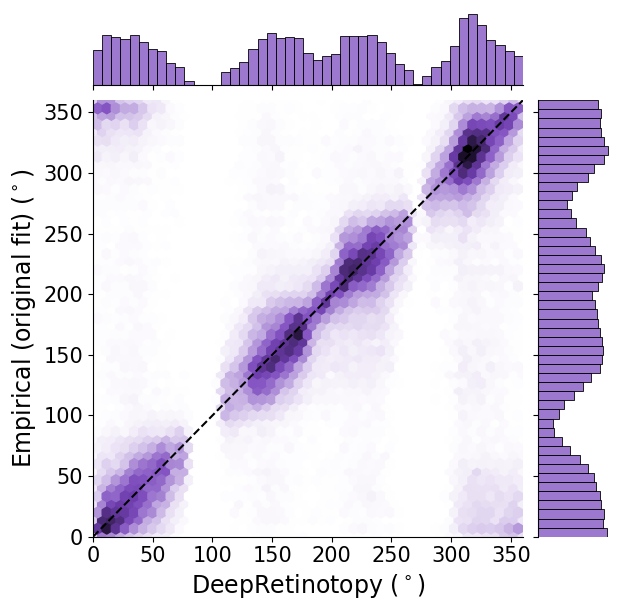

Saving plot to ../output_revision/model_evaluation/nyu/encoding_model_comparisons/MapVsMap_eccentricity_predicted_vs_empirical-original_both_0.1_earlyvisualcortex_hexbin.png and ../output_revision/model_evaluation/nyu/encoding_model_comparisons/MapVsMap_eccentricity_predicted_vs_empirical-original_both_0.1_earlyvisualcortex_hexbin.pdf


<Figure size 1000x1000 with 0 Axes>

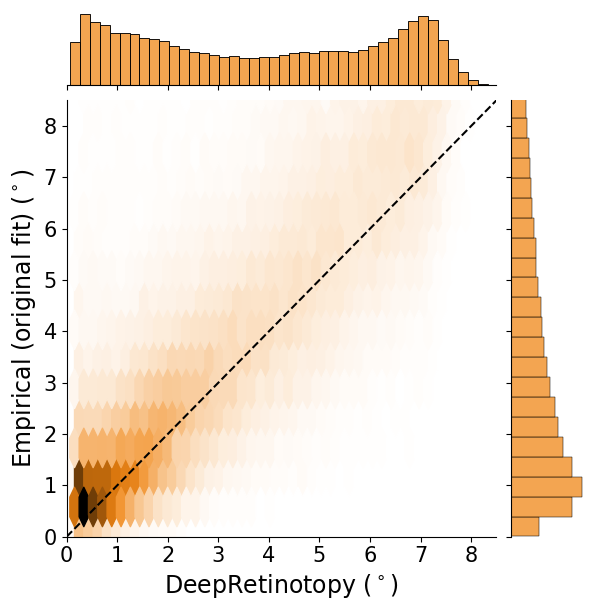

Saving plot to ../output_revision/model_evaluation/nyu/encoding_model_comparisons/MapVsMap_pRFsize_predicted_vs_empirical-original_both_0.1_earlyvisualcortex_hexbin.png and ../output_revision/model_evaluation/nyu/encoding_model_comparisons/MapVsMap_pRFsize_predicted_vs_empirical-original_both_0.1_earlyvisualcortex_hexbin.pdf


<Figure size 1000x1000 with 0 Axes>

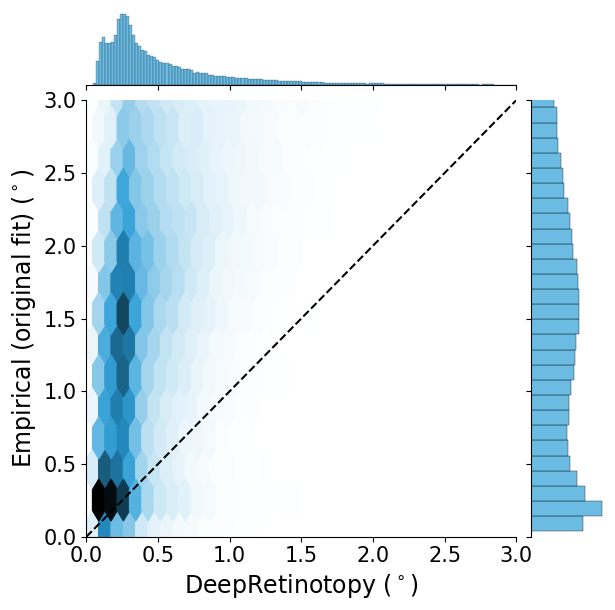

Region of interest: earlyvisualcortex
Excluded subjects: ['sub-wlsubj056']
Comparing DeepRetinotopy (x) against Empirical (analyzePRF) (y) in nyu, 42 subjects
Saving plot to ../output_revision/model_evaluation/nyu/encoding_model_comparisons/MapVsMap_polarAngle_predicted_vs_empirical-prfanalyze_both_0.1_earlyvisualcortex_hexbin.png and ../output_revision/model_evaluation/nyu/encoding_model_comparisons/MapVsMap_polarAngle_predicted_vs_empirical-prfanalyze_both_0.1_earlyvisualcortex_hexbin.pdf


<Figure size 1000x1000 with 0 Axes>

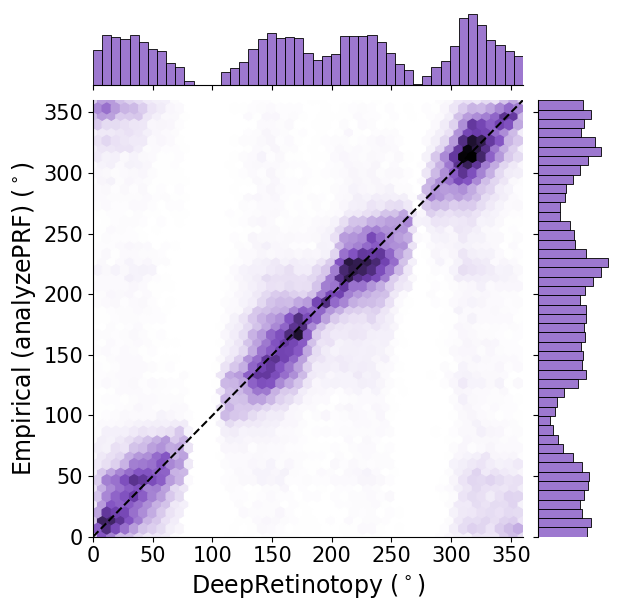

Saving plot to ../output_revision/model_evaluation/nyu/encoding_model_comparisons/MapVsMap_eccentricity_predicted_vs_empirical-prfanalyze_both_0.1_earlyvisualcortex_hexbin.png and ../output_revision/model_evaluation/nyu/encoding_model_comparisons/MapVsMap_eccentricity_predicted_vs_empirical-prfanalyze_both_0.1_earlyvisualcortex_hexbin.pdf


<Figure size 1000x1000 with 0 Axes>

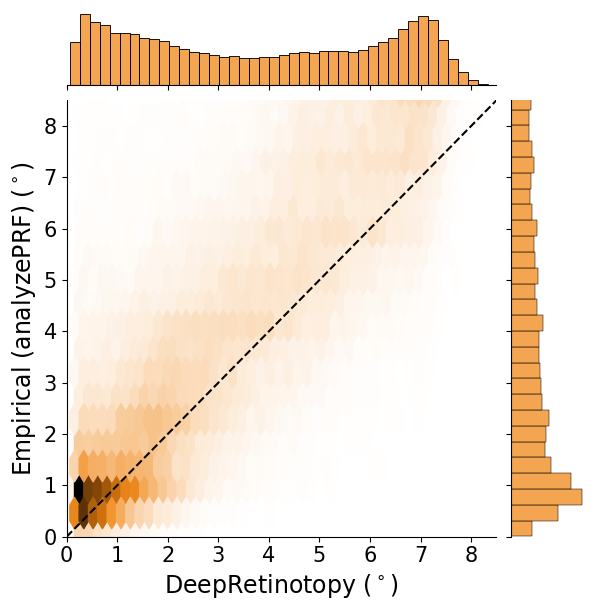

Saving plot to ../output_revision/model_evaluation/nyu/encoding_model_comparisons/MapVsMap_pRFsize_predicted_vs_empirical-prfanalyze_both_0.1_earlyvisualcortex_hexbin.png and ../output_revision/model_evaluation/nyu/encoding_model_comparisons/MapVsMap_pRFsize_predicted_vs_empirical-prfanalyze_both_0.1_earlyvisualcortex_hexbin.pdf


<Figure size 1000x1000 with 0 Axes>

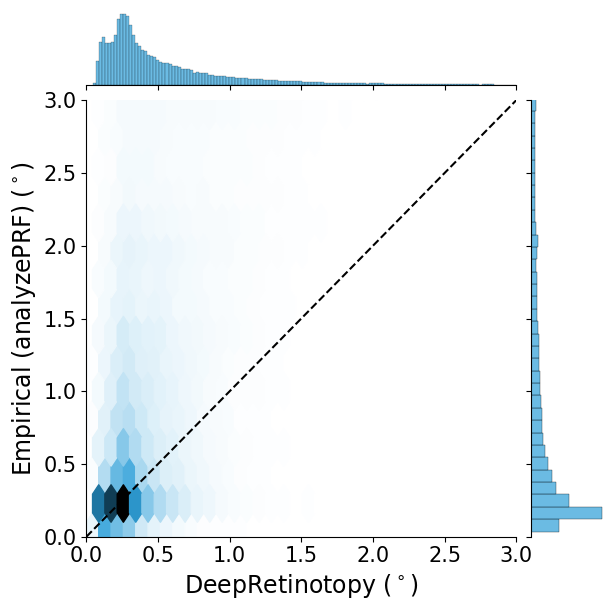

median   
dataset map_x                map_y                retinotopic_map hemisphere             
nyu     empirical-prfanalyze empirical-original   eccentricity    lh          0.903464  \
                                                                  rh          0.911610   
                                                  pRFsize         lh          0.876104   
                                                                  rh          0.899679   
                                                  polarAngle      lh          0.957060   
                                                                  rh          0.953957   
        predicted            empirical-original   eccentricity    lh          0.717528   
                                                                  rh          0.721199   
                                                  pRFsize         lh          0.718430   
                                                                  rh          0.740391   
                                                  polarAngle      lh          0.714701   
                                                                  rh          0.739344   
                             empirical-prfanalyze eccentricity    lh          0.786351   
                                                                  rh          0.794886   
                                                  pRFsize         lh          0.713616   
                                                                  rh          0.739435   
                                                  polarAngle      lh          0.699796   
                                                                  rh          0.729495   

                                                                                  mean   
dataset map_x                map_y                retinotopic_map hemisphere             
nyu     empirical-prfanalyze empirical-original   eccentricity    lh          0.899580  \
                                                                  rh          0.909562   
                                                  pRFsize         lh          0.871708   
                                                                  rh          0.896741   
                                                  polarAngle      lh          0.951291   
                                                                  rh          0.948931   
        predicted            empirical-original   eccentricity    lh          0.711256   
                                                                  rh          0.708867   
                                                  pRFsize         lh          0.700757   
                                                                  rh          0.734837   
                                                  polarAngle      lh          0.712826   
                                                                  rh          0.719322   
                             empirical-prfanalyze eccentricity    lh          0.777604   
                                                                  rh          0.787683   
                                                  pRFsize         lh          0.699995   
                                                                  rh          0.729877   
                                                  polarAngle      lh          0.696457   
                                                                  rh          0.711107   

                                                                              count  
dataset map_x                map_y                retinotopic_map hemisphere         
nyu     empirical-prfanalyze empirical-original   eccentricity    lh             42  
                                                                  rh             42  
                                                  pRFsize         lh             42  
                                                

In [4]:
# The original fit is the encoding model released with each dataset; 'prfanalyze' is the analyzePRF refit
comparisons = [(('empirical', 'prfanalyze'), ('empirical', None)),
               (('predicted', None), ('empirical', None)),
               (('predicted', None), ('empirical', 'prfanalyze'))]

# Subjects without an analyzePRF fit
excluded_subjects = {'nyu': ['sub-wlsubj056']}

correlation_scores = []
for dataset_name in ['nyu']:
    for map_x, map_y in comparisons:
        scores = map_vs_map(output_dir[dataset_name], dataset_name, map_x, map_y, retinotopic_maps,
                            hemispheres = 'both',
                            threshold = variance_explained_threshold[dataset_name],
                            region_of_interest = 'earlyvisualcortex',
                            output_dir = '../output_revision/',
                            excluded_subjects = excluded_subjects[dataset_name])
        scores['dataset'] = dataset_name
        correlation_scores.append(scores)
    base_path = f'../output_revision/model_evaluation/{dataset_name}/encoding_model_comparisons/'
    os.makedirs(base_path, exist_ok = True)
    pd.concat([scores for scores in correlation_scores if scores['dataset'].iloc[0] == dataset_name]).to_csv(f'{base_path}map_vs_map_{dataset_name}.csv', index = False)
correlation_scores = pd.concat(correlation_scores, ignore_index = True)

# Median correlation across subjects for each comparison
correlation_scores.groupby(['dataset', 'map_x', 'map_y', 'retinotopic_map', 'hemisphere'])['scores'].agg(['median', 'mean', 'count'])


## 5. Generate data for null distributions for statistical testing

In this section, we build a universal null distribution using spin permutations from HCP data to enable statistical testing of our prediction performance. The spin permutation method preserves the spatial autocorrelation structure of the data while generating null correlations. We then compare the observed correlations from each dataset (HCP, NYU, Stanford, CHN, Kiwi) against this null distribution to compute p-values and assess statistical significance.

In [3]:
import numpy as np
import nibabel as nib
import os
from brainspace.null_models import SpinPermutations
import pickle

def build_hcp_null_distribution(hcp_dataset_path, n_perm=1000, hemisphere = 'lh'):
    """
    Build universal null distribution from HCP empirical retinotopic maps
    
    Parameters:
    -----------
    hcp_dataset_path : str
        Path to HCP dataset
    n_perm : int
        Number of spatial permutations per subject
    n_subjects : int or None
        Number of HCP subjects to use (None = use all available)
    
    Returns:
    --------
    dict : Universal null correlations for each map type
    """
    import scipy
    from astropy.stats import circcorrcoef
    from astropy import units as u
    
    print("Building universal null distribution from HCP data...")
    if hemisphere == 'lh':
        hemi = 'L'
    else:
        hemi = 'R'
    # Load sphere surface for permutation
    sphere_gii = nib.load(f'../datasets/templates_2016/fs_LR-deformed_to-fsaverage.{hemi}.sphere.32k_fs_LR.surf.gii')
    sphere_coords = sphere_gii.darrays[0].data
    
    # Initialize null correlation storage
    universal_null = {
        'polarAngle': [],
        'eccentricity': [],
        'pRFsize': []
    }
    
    # Get list of HCP subjects
    hcp_subjects = ['680957', '191841', '617748', '725751', '198653',
                         '191336', '572045', '601127', '644246', '157336']
    
    print(f"Using {len(hcp_subjects)} HCP subjects to build null distribution")
    
    # Create spin permutation object
    spin = SpinPermutations(n_rep=n_perm, random_state=1234)
    spin.fit(sphere_coords)
    
    for subject_idx, subject in enumerate(hcp_subjects):
        print(f"Processing HCP subject {subject_idx+1}/{len(hcp_subjects)}: {subject}")
        
        # Load HCP empirical retinotopic maps
        try:
            empirical_polar = nib.load(f'{hcp_dataset_path}/{subject}/surf/{subject}.fs_empirical_polarAngle_{hemisphere}.func.gii')
            empirical_eccen = nib.load(f'{hcp_dataset_path}/{subject}/surf/{subject}.fs_empirical_eccentricity_{hemisphere}.func.gii')
            empirical_pRF_size = nib.load(f'{hcp_dataset_path}/{subject}/surf/{subject}.fs_empirical_pRFsize_{hemisphere}.func.gii')
            
            polar_data = empirical_polar.darrays[0].data
            eccen_data = empirical_eccen.darrays[0].data
            sigma_data = empirical_pRF_size.darrays[0].data
            
        except FileNotFoundError:
            print(f"  Skipping {subject} - retinotopic files not found")
            continue
        
        # Generate permutations
        polar_permutations = spin.randomize(polar_data)
        eccen_permutations = spin.randomize(eccen_data)
        sigma_permutations = spin.randomize(sigma_data)
        
        # For each permutation, compute "self-correlation" 
        # (this gives us the null distribution of spatial correlations)
        valid_perms = 0
        for i in range(len(polar_permutations)):
            perm_polar = polar_permutations[i]
            perm_eccen = eccen_permutations[i]
            perm_sigma = sigma_permutations[i]
            
            # Compute correlations between original and permuted (null correlation)
            polar_mask = ~(np.isnan(polar_data) | np.isnan(perm_polar))
            eccen_mask = ~(np.isnan(eccen_data) | np.isnan(perm_eccen))
            sigma_mask = ~(np.isnan(sigma_data) | np.isnan(perm_sigma))
            
            # Only keep if we have enough valid vertices
            if np.sum(polar_mask) > 100:  # At least 100 valid vertices
                polar_null_corr = circcorrcoef(polar_data[polar_mask]*u.deg, perm_polar[polar_mask]*u.deg)
                if not np.isnan(polar_null_corr):
                    universal_null['polarAngle'].append(polar_null_corr)
            
            if np.sum(eccen_mask) > 100:
                eccen_null_corr = scipy.stats.pearsonr(eccen_data[eccen_mask], perm_eccen[eccen_mask])[0]
                if not np.isnan(eccen_null_corr):
                    universal_null['eccentricity'].append(eccen_null_corr)
            
            if np.sum(sigma_mask) > 100:
                sigma_null_corr = scipy.stats.pearsonr(sigma_data[sigma_mask], perm_sigma[sigma_mask])[0]
                if not np.isnan(sigma_null_corr):
                    universal_null['pRFsize'].append(sigma_null_corr)
            
            valid_perms += 1
        
        print(f"  Added {valid_perms} null correlations from {subject}")
    
    # Summary statistics
    print("\n" + "="*60)
    print("UNIVERSAL NULL DISTRIBUTION SUMMARY")
    print("="*60)
    for map_type in ['polarAngle', 'eccentricity', 'pRFsize']:
        null_corrs = universal_null[map_type]
        print(f"{map_type}:")
        print(f"  Total null correlations: {len(null_corrs)}")
        print(f"  Mean: {np.mean(null_corrs):.4f}")
        print(f"  Std: {np.std(null_corrs):.4f}")
        print(f"  95th percentile: {np.percentile(null_corrs, 95):.4f}")
        print(f"  99th percentile: {np.percentile(null_corrs, 99):.4f}")
    
    return universal_null

def save_null_distribution(null_dist, filename='hcp_universal_null_distribution.pkl'):
    """Save the null distribution for future use"""
    with open(filename, 'wb') as f:
        pickle.dump(null_dist, f)
    print(f"Null distribution saved to {filename}")

def load_null_distribution(filename='hcp_universal_null_distribution.pkl'):
    """Load previously computed null distribution"""
    with open(filename, 'rb') as f:
        null_dist = pickle.load(f)
    return null_dist

def compare_to_hcp_null(observed_correlations, null_dist, map_type):
    """
    Compare observed correlations to HCP-derived null distribution
    
    Parameters:
    -----------
    observed_correlations : array-like
        Your observed correlations (e.g., from NYU, NSD, etc.)
    null_dist : dict
        HCP null distribution from build_hcp_null_distribution()
    map_type : str
        'polarAngle' or 'eccentricity'
    
    Returns:
    --------
    dict : Statistical results
    """
    
    null_corrs = np.array(null_dist[map_type])
    obs_corrs = np.array(observed_correlations)
    
    results = {
        'observed_correlations': obs_corrs,
        'null_correlations': null_corrs,
        'p_value': [],
        'effect_size': [],
        'null_percentile': []
    }
    
    # Compute statistics for each observed correlation
    obs_corr = np.mean(obs_corrs)
    # P-value: proportion of null correlations >= observed
    p_value = np.sum(null_corrs >= obs_corr) / len(null_corrs)
    
    # Effect size: how many standard deviations above null mean
    effect_size = (obs_corr - np.mean(null_corrs)) / np.std(null_corrs)
    
    # Percentile in null distribution
    percentile = 100 * np.sum(null_corrs <= obs_corr) / len(null_corrs)
    
    results['p_value'].append(p_value)
    results['effect_size'].append(effect_size)
    results['null_percentile'].append(percentile)

    return results

def create_publication_summary(results_dict, dataset_names, hemisphere):
    """
    Create publication-ready summary of results across datasets
    """
    import pandas as pd
    
    print("\n" + "="*80)
    print("PUBLICATION SUMMARY: COMPARISON TO HCP NULL DISTRIBUTION")
    print("="*80)
    
    # Collect data for table
    table_data = []
    
    for dataset in dataset_names:
        if dataset not in results_dict:
            continue
            
        for map_type in ['polarAngle', 'eccentricity', 'pRFsize']:
            if map_type not in results_dict[dataset]:
                continue
                
            results = results_dict[dataset][map_type]
            obs_corrs = results['observed_correlations']
            p_value = results['p_value'][0]  # Extract single value from list
            effect_size = results['effect_size'][0]
            
            # Summary statistics
            mean_corr = np.mean(obs_corrs)
            
            table_data.append({
                'dataset_name': dataset,
                'hemisphere': hemisphere,
                'map': map_type,
                'correlation_score': round(mean_corr, 4),
                'p_value': round(p_value, 4) if p_value >= 0.001 else f"{p_value:.2e}"
            })
    
    # Create and display table
    summary_table = pd.DataFrame(table_data)
    print(summary_table.to_string(index=False))
    base_path = f'../output_revision/model_evaluation/'
    summary_table.to_csv(f'{base_path}performance_across_datasets_{hemisphere}.csv')
    
    return summary_table


In [9]:
# Step 1: Build universal null from HCP (run once)
for hemisphere in ['lh', 'rh']:
    null = build_hcp_null_distribution('../datasets/hcp_training/freesurfer', n_perm=1000, hemisphere=hemisphere)
    save_null_distribution(null, f'hcp_universal_null_{hemisphere}.pkl')

Building universal null distribution from HCP data...
Using 10 HCP subjects to build null distribution
Processing HCP subject 1/10: 680957
  Added 1000 null correlations from 680957
Processing HCP subject 2/10: 191841
  Added 1000 null correlations from 191841
Processing HCP subject 3/10: 617748
  Added 1000 null correlations from 617748
Processing HCP subject 4/10: 725751
  Added 1000 null correlations from 725751
Processing HCP subject 5/10: 198653
  Added 1000 null correlations from 198653
Processing HCP subject 6/10: 191336
  Added 1000 null correlations from 191336
Processing HCP subject 7/10: 572045
  Added 1000 null correlations from 572045
Processing HCP subject 8/10: 601127
  Added 1000 null correlations from 601127
Processing HCP subject 9/10: 644246
  Added 1000 null correlations from 644246
Processing HCP subject 10/10: 157336
  Added 1000 null correlations from 157336

UNIVERSAL NULL DISTRIBUTION SUMMARY
polarAngle:
  Total null correlations: 10000
  Mean: 0.0006
  Std: 0.

In [4]:
for hemisphere in ['lh', 'rh']:
    results_across_datasets = {}
    for dataset_name in ['hcp', 'nyu', 'stanford', 'chn', 'kiwi']:
        # Step 2: Load observed corraletions and null distribution
        base_path = f'../output_revision/model_evaluation/{dataset_name}/'
        null = load_null_distribution(f'hcp_universal_null_{hemisphere}.pkl')
        corr_table = pd.read_csv(f'{base_path}prediction_performance_{dataset_name}.csv')

        # Step 3: Compare each dataset to the HCP null
        results_all = {}
        for retinotopic_map in ['polarAngle', 'eccentricity', 'pRFsize']:
            correlations = corr_table.query(f"hemisphere == '{hemisphere}' and retinotopic_map == '{retinotopic_map}'")['scores']
            correlations = list(correlations)
            results = compare_to_hcp_null(correlations, null, retinotopic_map)
            results_all[retinotopic_map] = results

        results_across_datasets[dataset_name] = {'polarAngle': results_all['polarAngle'],
                        'eccentricity': results_all['eccentricity'],
                        'pRFsize': results_all['pRFsize']}
        
    create_publication_summary(results_across_datasets, ['hcp', 'nyu', 'stanford', 'chn', 'kiwi'], hemisphere)


PUBLICATION SUMMARY: COMPARISON TO HCP NULL DISTRIBUTION
dataset_name hemisphere          map  correlation_score  p_value
         hcp         lh   polarAngle             0.8492 0.00e+00
         hcp         lh eccentricity             0.8767 0.00e+00
         hcp         lh      pRFsize             0.6968 0.00e+00
         nyu         lh   polarAngle             0.7111 0.00e+00
         nyu         lh eccentricity             0.7061 0.00e+00
         nyu         lh      pRFsize             0.7039 0.00e+00
    stanford         lh   polarAngle             0.6997 0.00e+00
    stanford         lh eccentricity             0.6886 0.00e+00
    stanford         lh      pRFsize             0.6418 0.00e+00
         chn         lh   polarAngle             0.8201 0.00e+00
         chn         lh eccentricity             0.8336 0.00e+00
         chn         lh      pRFsize             0.4485 0.00e+00
        kiwi         lh   polarAngle             0.6819 0.00e+00
        kiwi         lh eccentri

## 6. Comparing median maps across datasets

We also perform cross-dataset comparisons to illustrate how pRF parameter estimates vary systematically with experimental factors such as fMRI preprocessing and visual stimuli as shown in Supplementary Figures 5, 6, and 7.

In [43]:
import os
import matplotlib.pyplot as plt 
from functions.evaluation import roi_earlyvisualcortex, create_mask

## Region of interest used for training
final_mask_L_ROI, final_mask_R_ROI, index_L_mask, index_R_mask = roi(['ROI'])
## Early visual cortex
final_mask_L, final_mask_R, index_L_mask, index_R_mask = roi_earlyvisualcortex(['ROI'])
# Final mask
ROI_masked, mask = create_mask(final_mask_L_ROI, final_mask_R_ROI, 
                               final_mask_L, final_mask_R, 'lh')
mask = mask[ROI_masked == 1]

In [44]:
def median_maps(path_to_freesurfer, list_of_subs, dataset = 'hcp', retinotopic_map = 'pRFsize', hemisphere = 'lh'):
    """Median empirical map across subjects, with the median variance explained.

    Polar angle and eccentricity are converted to cartesian coordinates (x, y) of the pRF centre before the
    median is taken, and back afterwards, so that the median is not taken across the 0/360 wrap of the angle
    and both maps describe the same median pRF centre.
    """
    retinotopic_maps = []
    variance_explained_maps = []
    for sub in list_of_subs:
        if retinotopic_map == 'polarAngle' or retinotopic_map == 'eccentricity':
            maps_to_load = ['polarAngle', 'eccentricity']
        else:
            maps_to_load = [retinotopic_map]
        loaded_maps = {}
        for map_to_load in maps_to_load:
            if dataset == 'chn' or dataset == 'kiwi':
                data = RetinotopyData_logbar(path_to_freesurfer, sub, hemisphere, map_to_load, experiment=experiment_datasets[dataset])
            else:
                data = RetinotopyData(path_to_freesurfer, sub, hemisphere, map_to_load)
            data.apply_mask_to_maps(ROI_masked)
            data.apply_mask_to_maps(mask)
            data.normalize_polarangle_convention()
            loaded_maps[map_to_load] = data.empirical_map
        if retinotopic_map == 'polarAngle' or retinotopic_map == 'eccentricity':
            # Cartesian coordinates of the pRF centre
            angle = np.radians(loaded_maps['polarAngle'])
            retinotopic_maps.append(np.stack([loaded_maps['eccentricity'] * np.cos(angle),
                                              loaded_maps['eccentricity'] * np.sin(angle)]))
        else:
            retinotopic_maps.append(loaded_maps[retinotopic_map])
        variance_explained_maps.append(data.variance_explained)
    retinotopic_maps = np.array(retinotopic_maps)
    median_map = np.median(retinotopic_maps, axis=0)
    # Back to polar coordinates
    if retinotopic_map == 'polarAngle':
        median_map = np.degrees(np.arctan2(median_map[1], median_map[0])) % 360
    elif retinotopic_map == 'eccentricity':
        median_map = np.hypot(median_map[0], median_map[1])
    return median_map, np.median(variance_explained_maps, axis=0)


In [47]:
def dataset_vs_dataset(dataset_1_name, dataset_2_name):
    """
    Compare two datasets by plotting their retinotopic maps.
    Args:
        dataset_1_name (str): Name of the first dataset.
        dataset_2_name (str): Name of the second dataset.
    """
    for retinotopic_map in ['polarAngle', 'eccentricity', 'pRFsize']:
        dataset_1_maps = []
        average_var_dataset1_maps = []
        dataset_2_maps = []
        average_var_dataset2_maps =[]

        for hemisphere in ['lh', 'rh']:
            list_of_subs_1 = []
            for sub in os.listdir(output_dir[dataset_1_name]):
                if not sub.startswith('processed') and not sub.startswith('.DS_Store') \
                    and not sub.startswith('logs') and not sub.startswith('fsaverage') \
                    and not sub.startswith('remove') and not sub.endswith('.log'):
                    list_of_subs_1.append(sub)
            list_of_subs_2 = []
            for sub in os.listdir(output_dir[dataset_2_name]):
                if not sub.startswith('processed') and not sub.startswith('.DS_Store') and not sub.startswith('logs') and not sub.startswith('fsaverage') \
                    and not sub.startswith('remove') and not sub.endswith('.log'):
                    list_of_subs_2.append(sub)
            dataset_1, average_var_dataset1 = median_maps(output_dir[dataset_1_name], list_of_subs_1, 
                                                            dataset = dataset_1_name, retinotopic_map = retinotopic_map, hemisphere=hemisphere)
            dataset_2, average_var_dataset2 = median_maps(output_dir[dataset_2_name], list_of_subs_2,
                                                                    dataset= dataset_2_name, retinotopic_map = retinotopic_map, hemisphere=hemisphere)
            if retinotopic_map == 'variance_explained':
                dataset_2 = dataset_2 / 100  # Convert to percentage
            dataset_1_maps.append(dataset_1)
            average_var_dataset1_maps.append(average_var_dataset1)
            dataset_2_maps.append(dataset_2)
            average_var_dataset2_maps.append(average_var_dataset2)
        dataset_1_maps = np.array(dataset_1_maps).reshape(-1)
        average_var_dataset1_maps = np.array(average_var_dataset1_maps).reshape(-1)
        dataset_2_maps = np.array(dataset_2_maps).reshape(-1)
        average_var_dataset2_maps = np.array(average_var_dataset2_maps).reshape(-1)
        if dataset_2_name == 'hcp':
            threshold = 15
        else:
            threshold = 0.15
        if retinotopic_map != 'variance_explained':
            plt.scatter(x=dataset_1_maps[average_var_dataset2_maps>threshold], y=dataset_2_maps[average_var_dataset2_maps>threshold], c = 'gray', marker = 'o', alpha= .3)
        else:
            plt.scatter(x=dataset_1_maps[average_var_dataset2_maps>threshold], y=dataset_2_maps[average_var_dataset2_maps>threshold],  c = 'gray', marker = 'o', alpha= .3)
        dataset_plot_name = {'hcp':'HCP', 'nyu': 'NYU', 'stanford': 'Stanford', 'chn': 'CHN', 'kiwi': 'New Zealand'}
        if retinotopic_map == 'polarAngle':
            plt.plot([0, 360], [0, 360], 'k--')
            plt.xlim([0, 360])
            plt.ylim([0, 360])
            plt.xlabel('')
            plt.ylabel('')
            # plt.xlabel('Polar angle from ' + dataset_plot_name[dataset_1_name])
            # plt.ylabel('Polar angle from ' + dataset_plot_name[dataset_2_name])
        elif retinotopic_map == 'eccentricity':
            plt.plot([0, 8], [0, 8], 'k--')
            plt.xlim([0, 8])
            plt.ylim([0, 8])
            plt.xlabel('')
            plt.ylabel('')
            # plt.xlabel('Eccentricity from ' + dataset_plot_name[dataset_1_name])
            # plt.ylabel('Eccentricity from ' + dataset_plot_name[dataset_2_name])
        elif retinotopic_map == 'pRFsize':
            plt.plot([0, 3], [0, 3], 'k--')
            plt.xlim([0, 3])
            plt.xticks([0, 1, 2, 3])
            plt.ylim([0, 3])
            plt.yticks([0, 1, 2, 3])
            plt.xlabel('')
            plt.ylabel('')
            # plt.xlabel('pRF size from ' + dataset_plot_name[dataset_1_name])
            # plt.ylabel('pRF size from ' + dataset_plot_name[dataset_2_name])
        else:
            plt.plot([0, 1], [0, 1], 'k--')
            plt.xlim([0, 1])
            plt.ylim([0, 1])
            plt.xlabel('Variance explained ' + dataset_plot_name[dataset_1_name])
            plt.ylabel('Variance explained ' + dataset_plot_name[dataset_2_name])
        if not os.path.exists('../output_revision/datasets_comparisons'):
            os.makedirs('../output_revision/datasets_comparisons', exist_ok=True)
        plt.tick_params(labelsize=20)
        plt.savefig(f'../output_revision/datasets_comparisons/{dataset_2_name}_vs_{dataset_1_name}_{retinotopic_map}.png', dpi=300)
        plt.show()

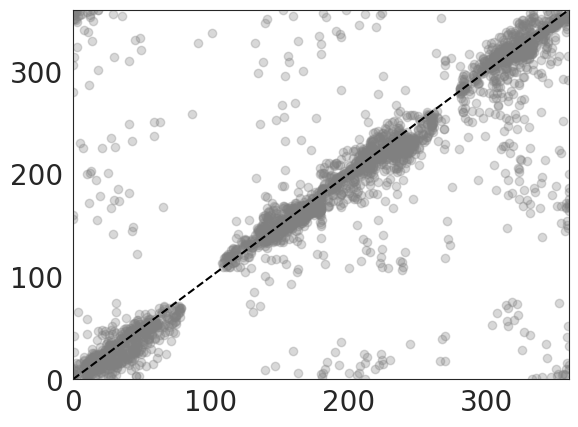

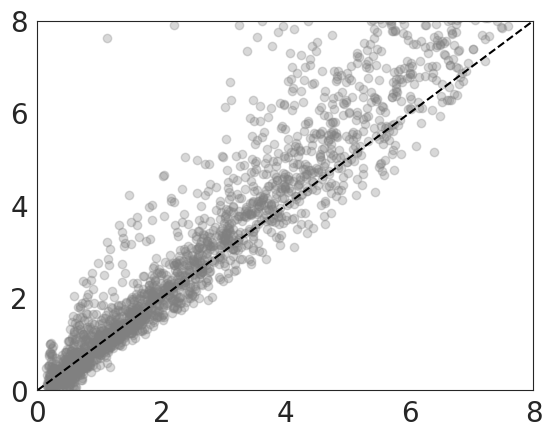

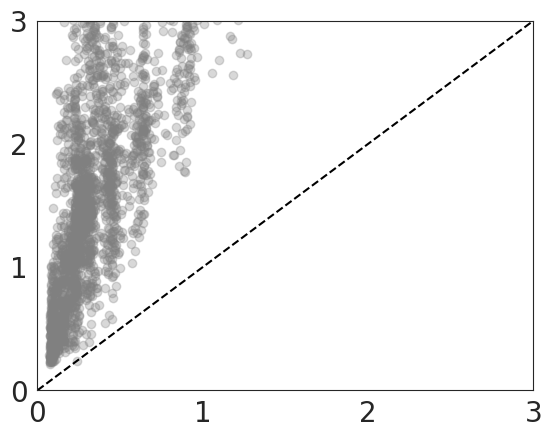

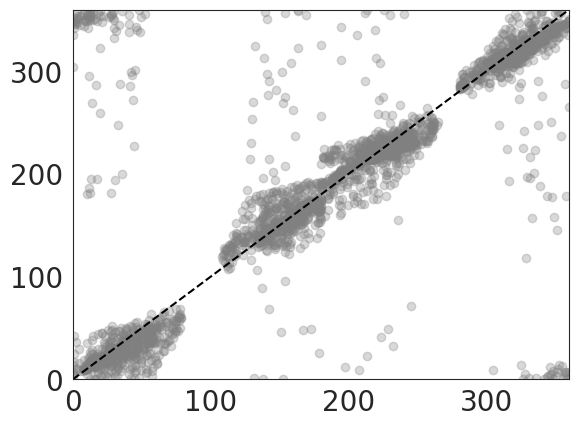

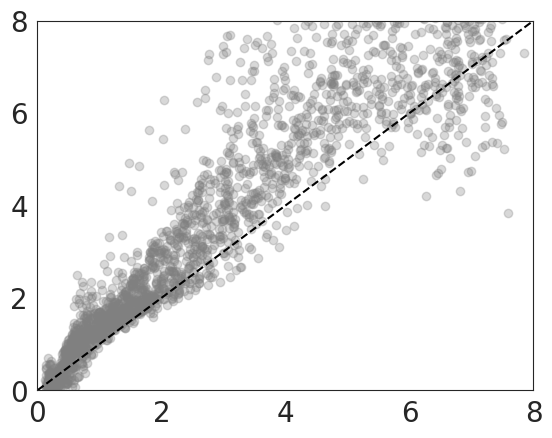

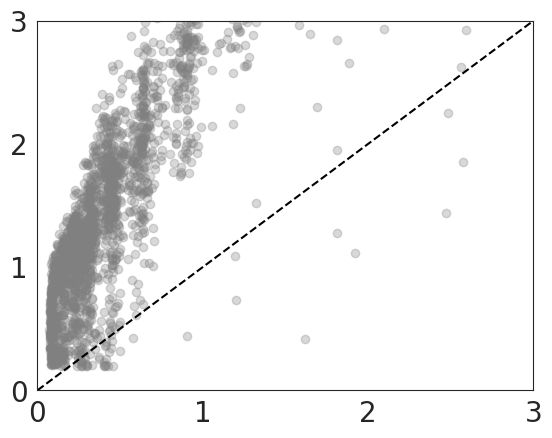

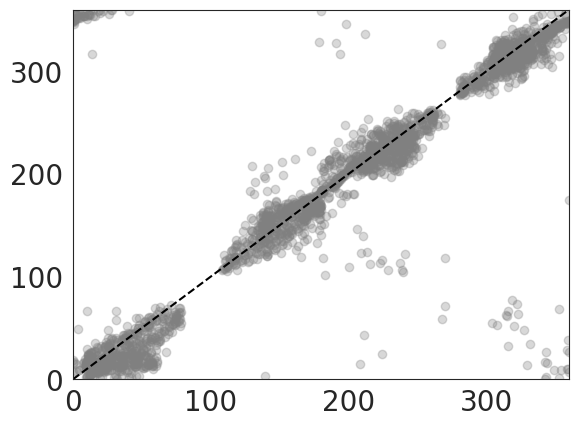

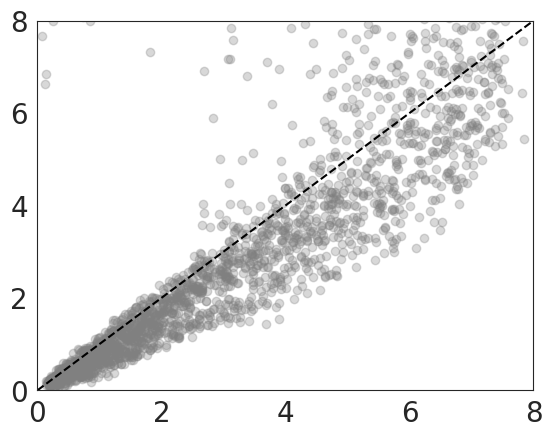

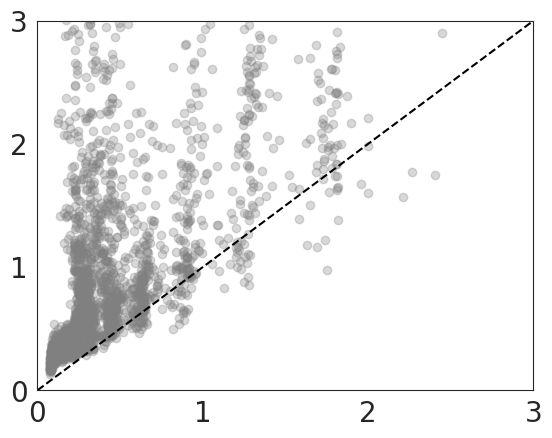

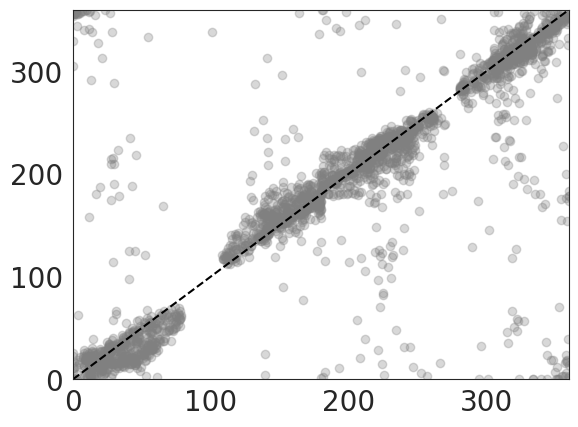

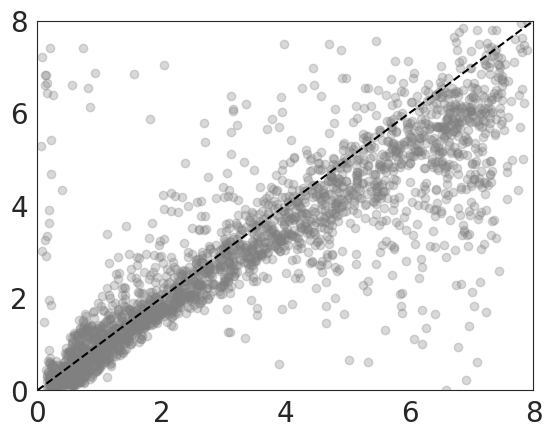

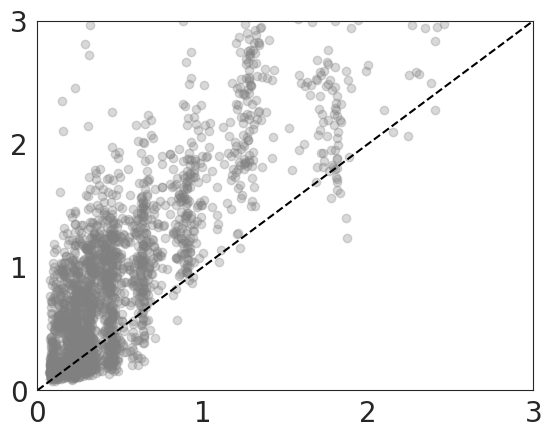

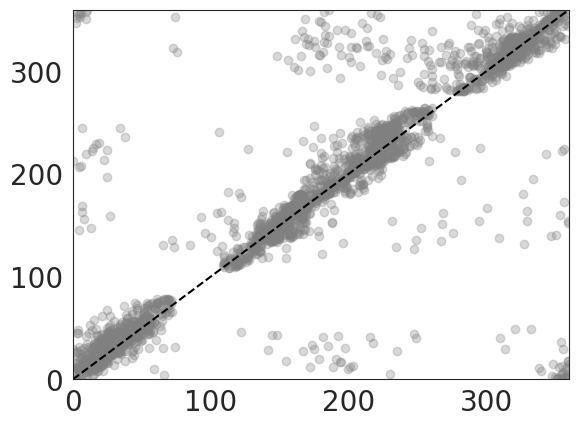

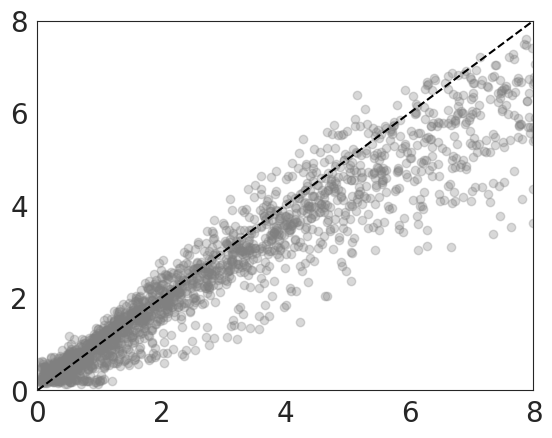

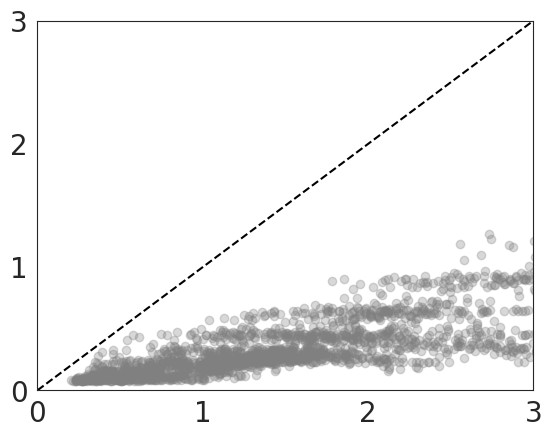

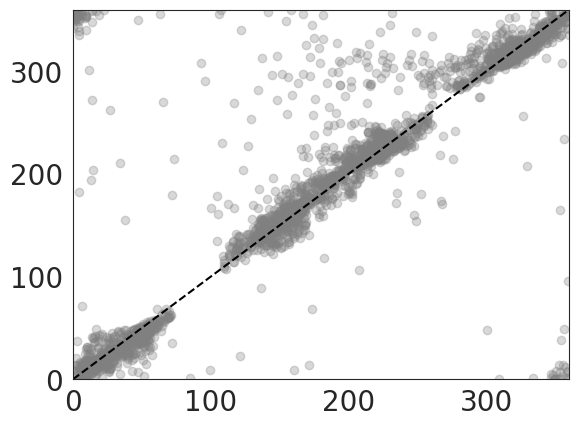

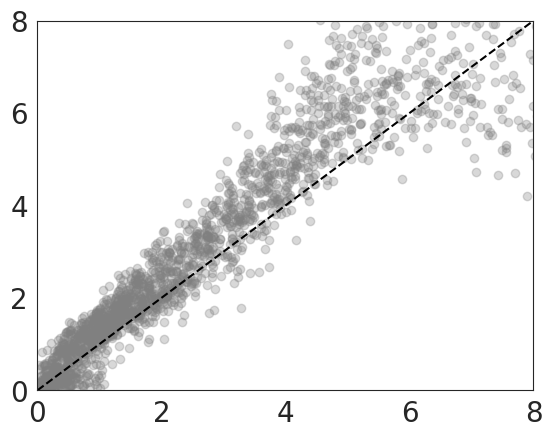

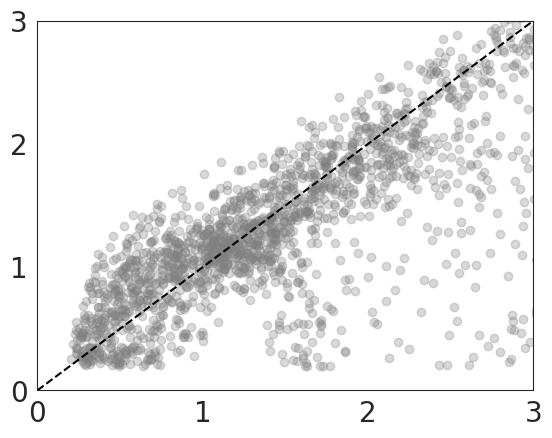

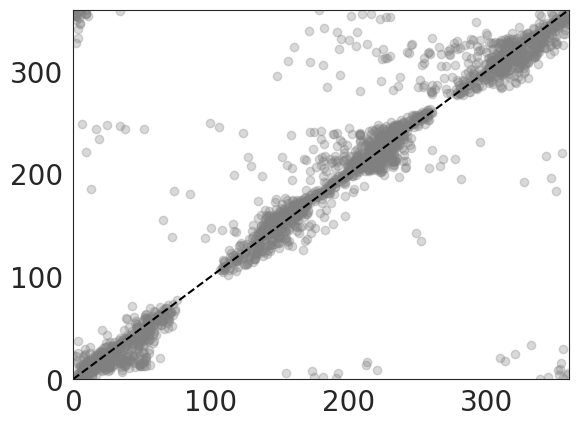

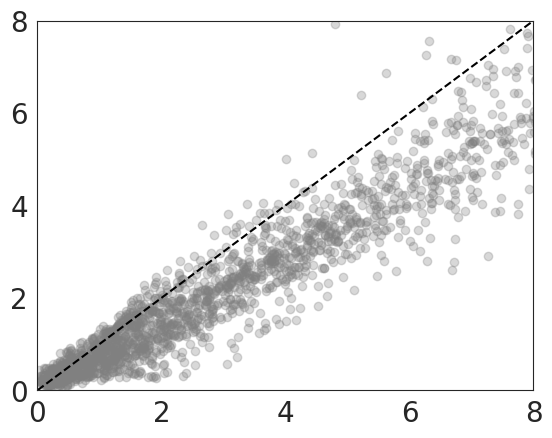

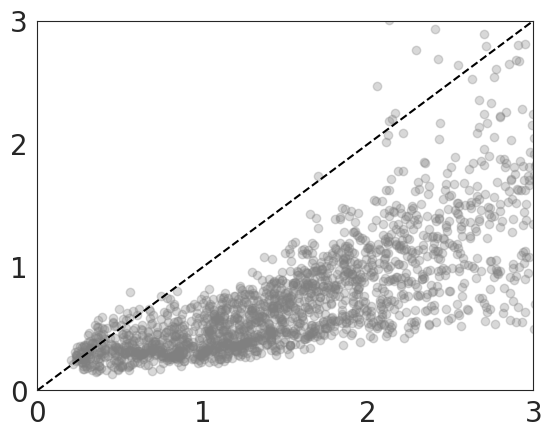

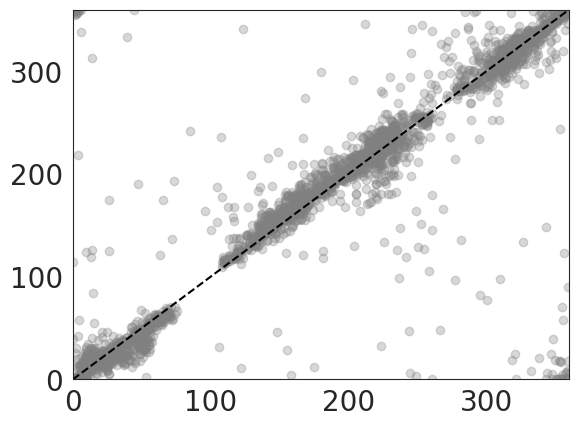

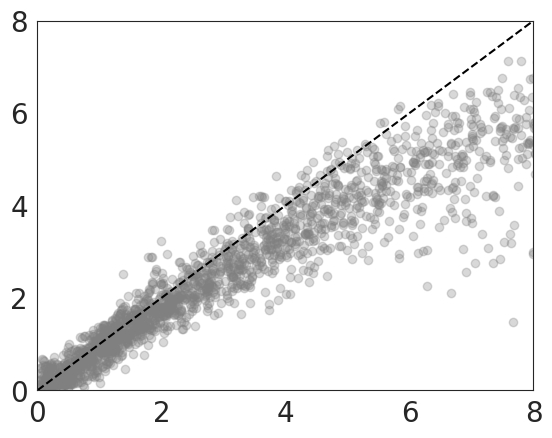

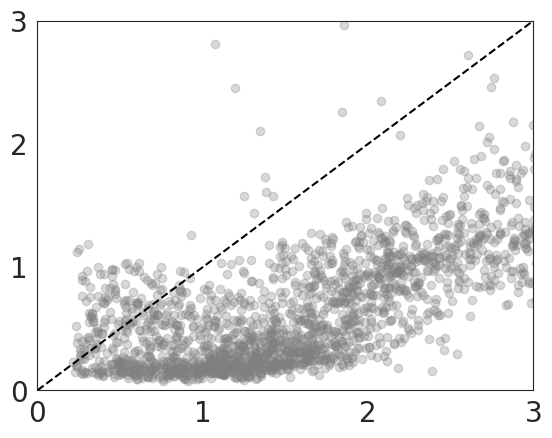

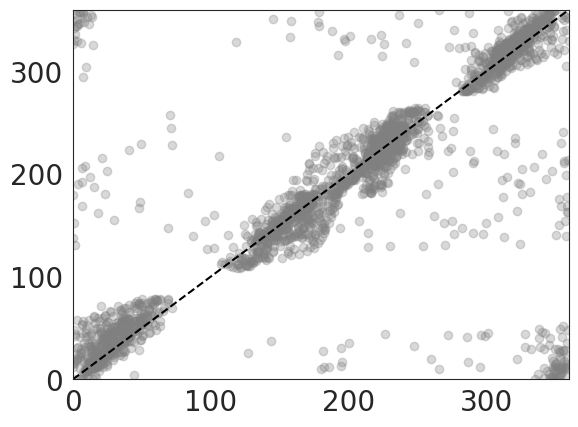

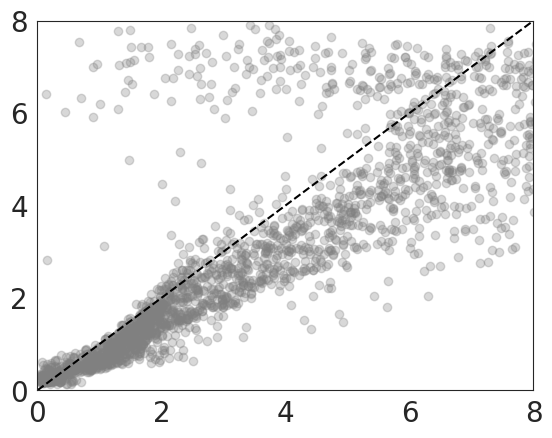

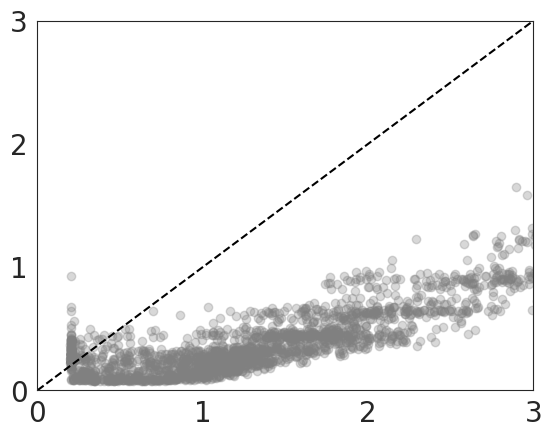

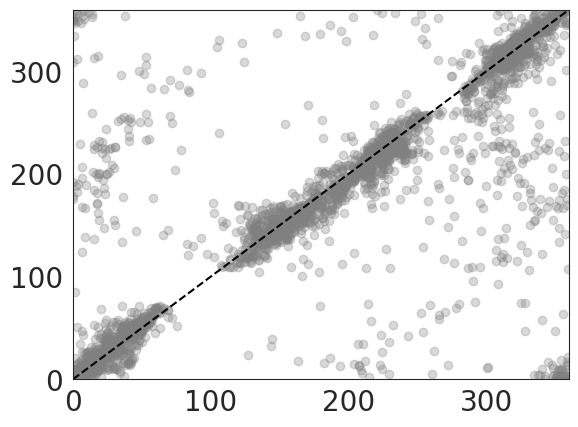

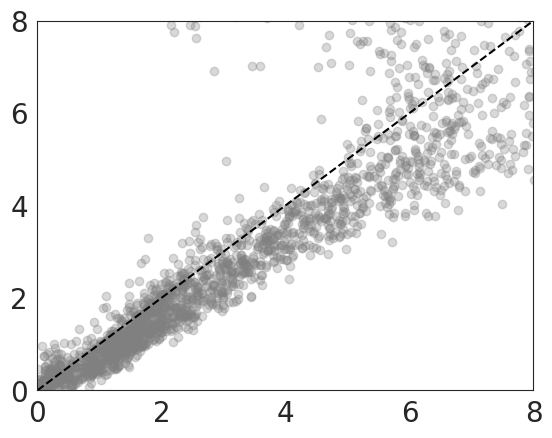

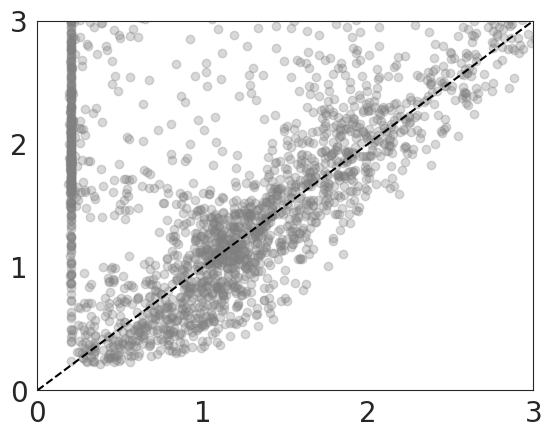

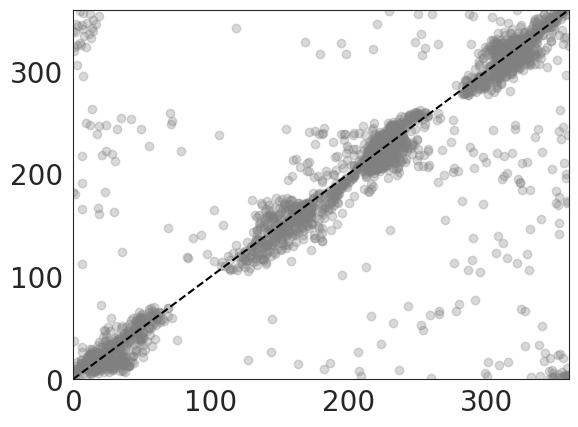

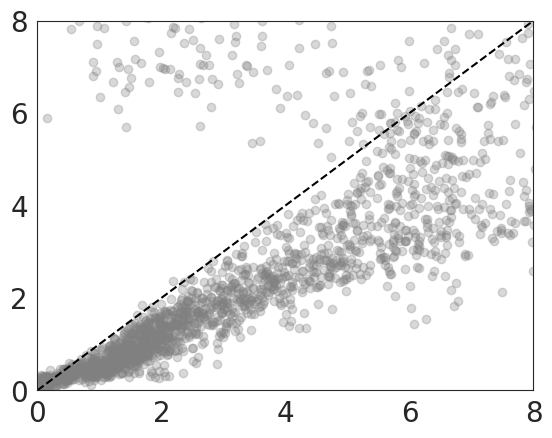

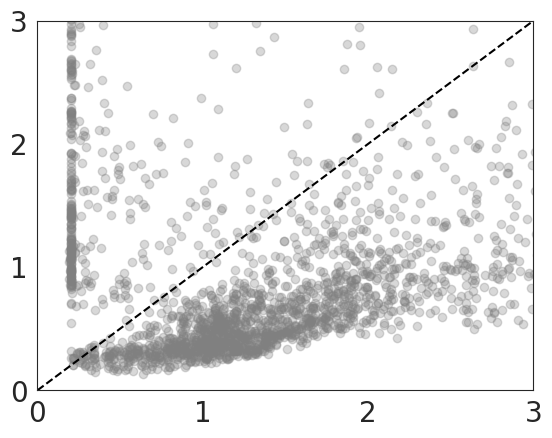

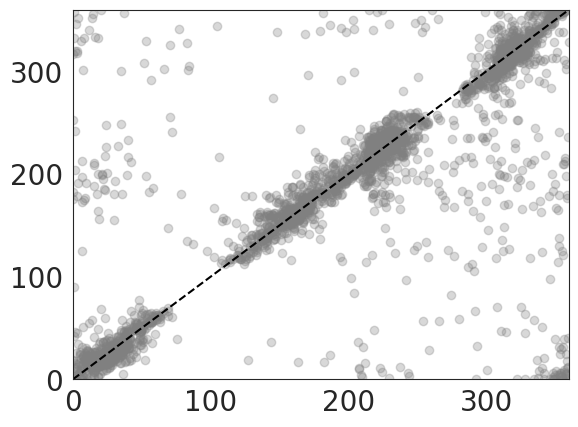

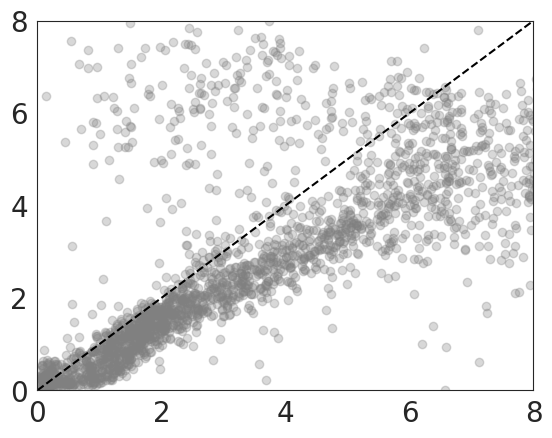

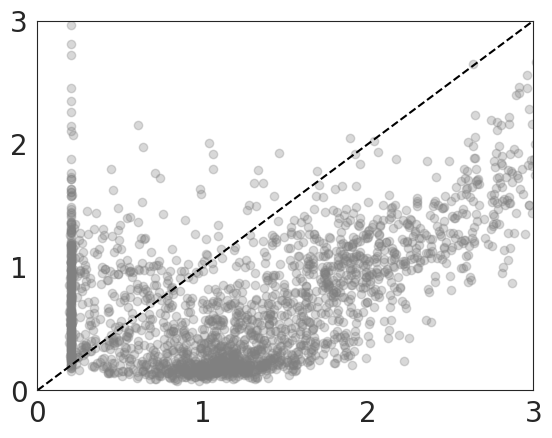

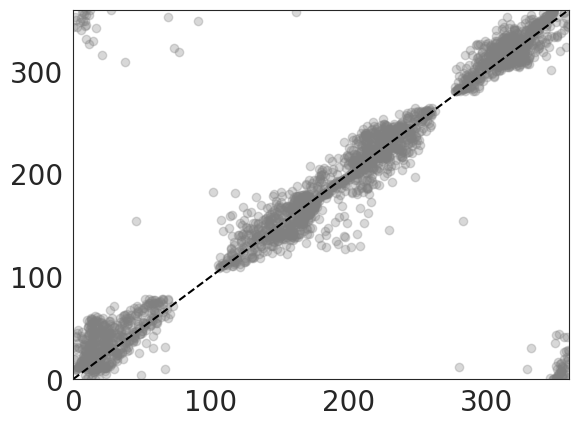

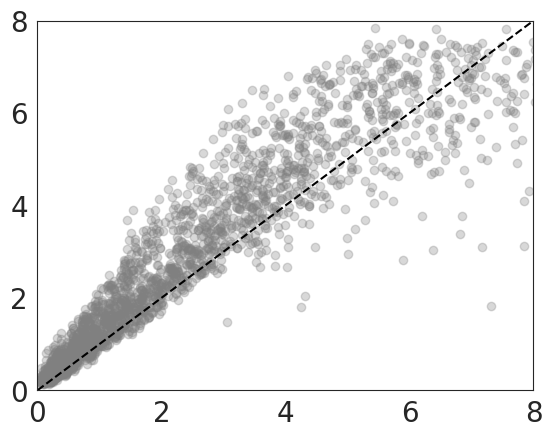

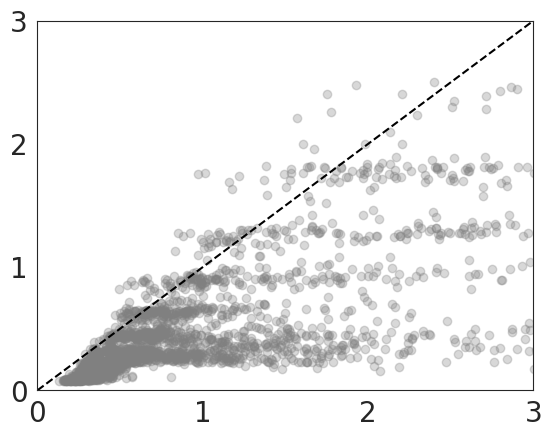

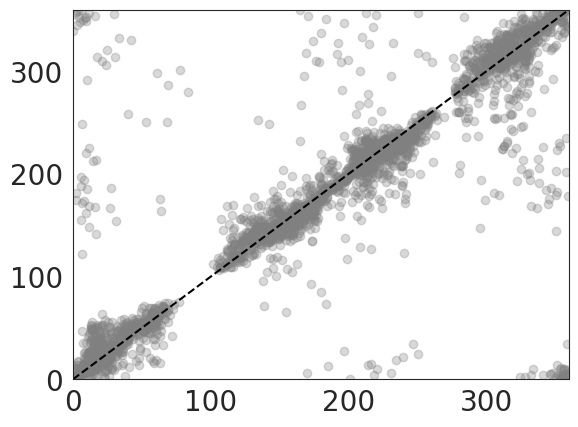

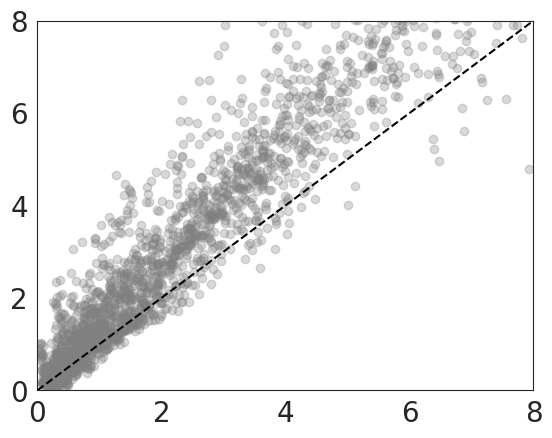

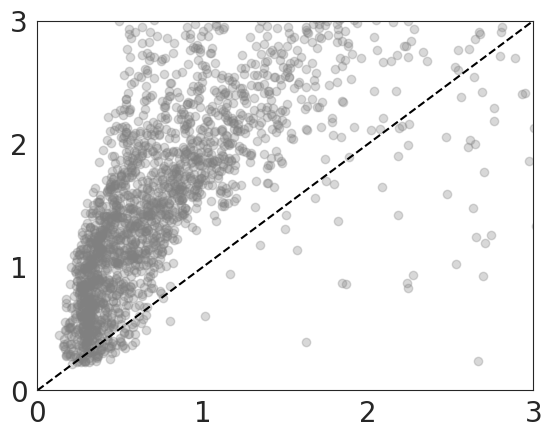

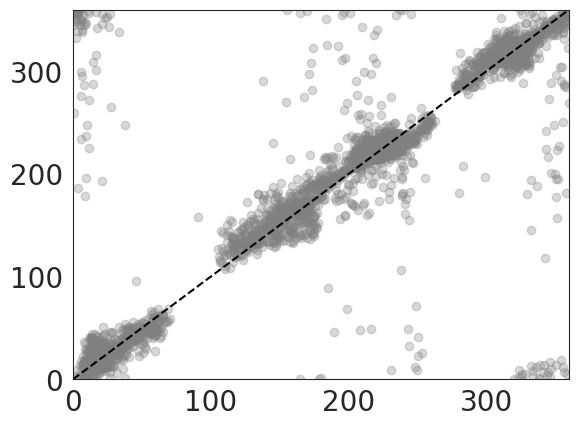

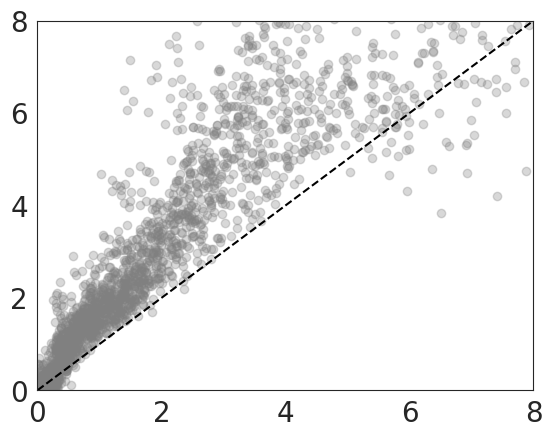

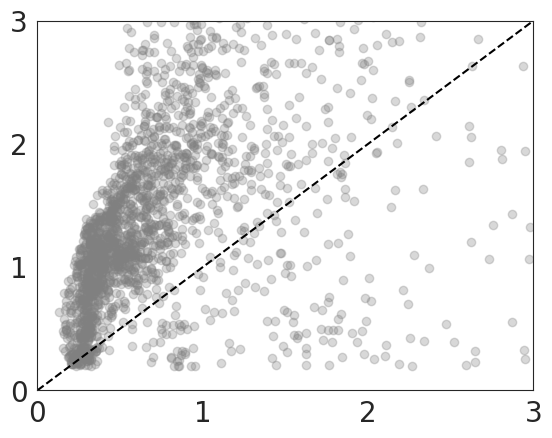

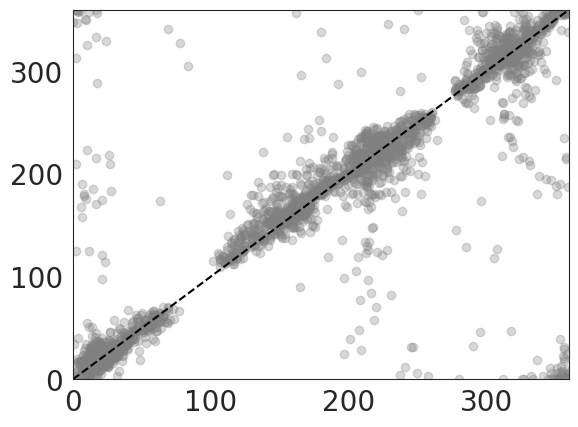

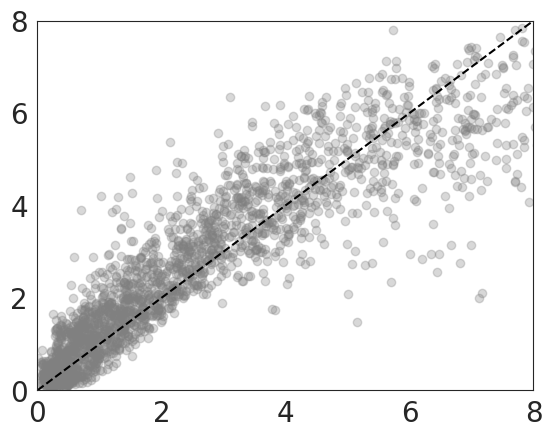

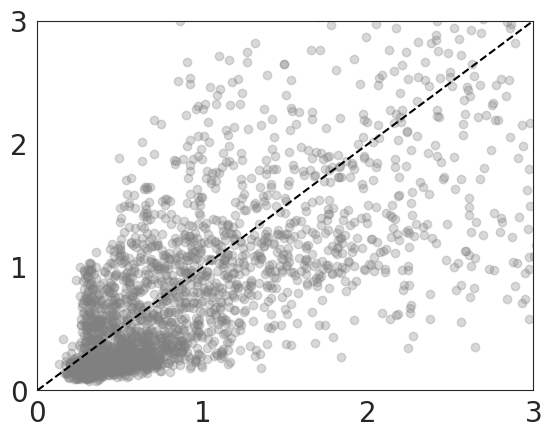

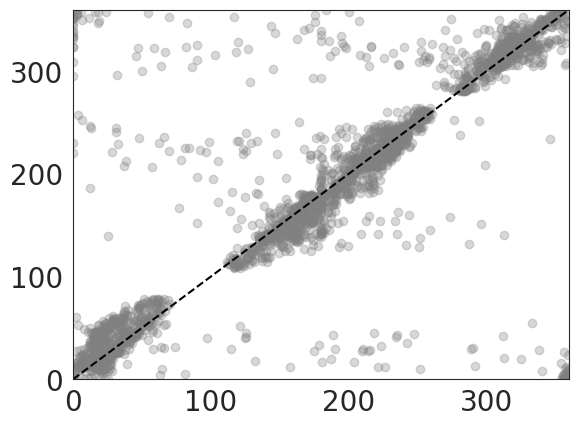

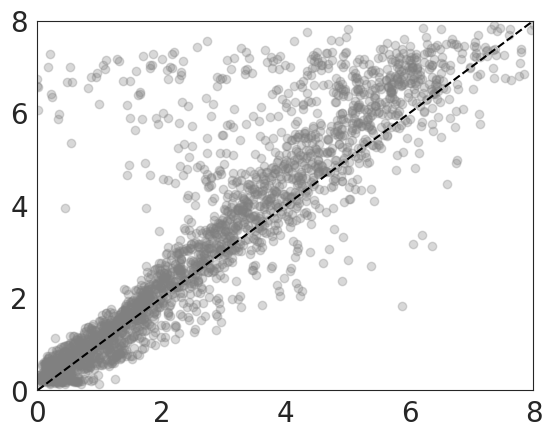

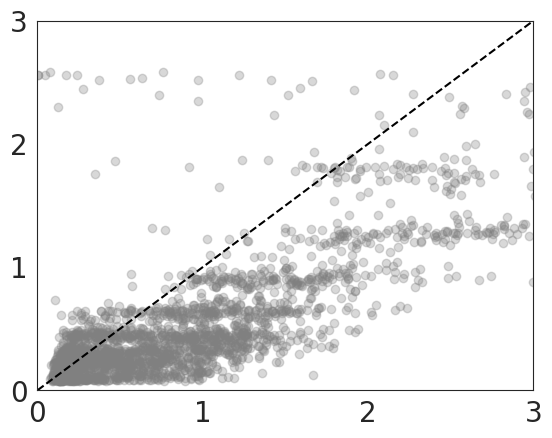

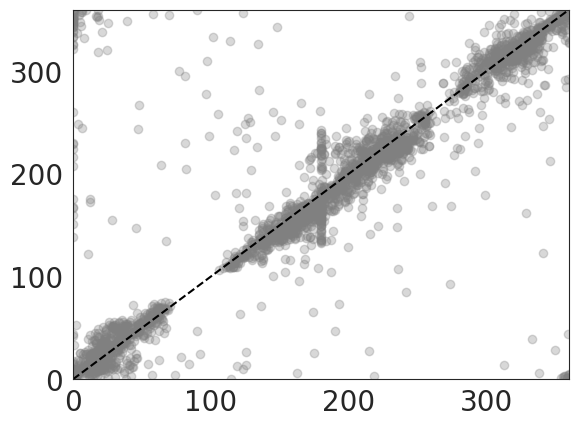

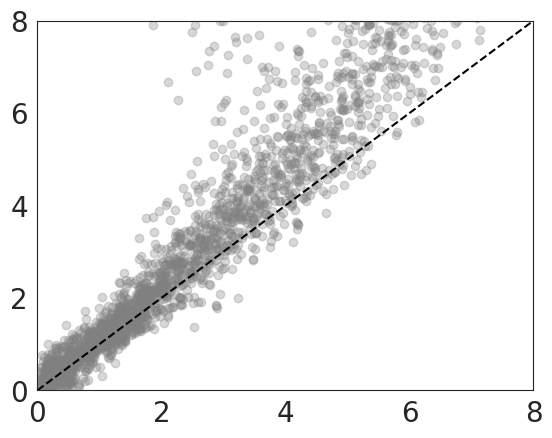

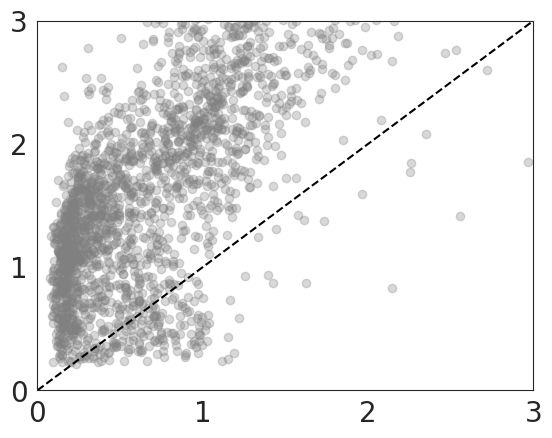

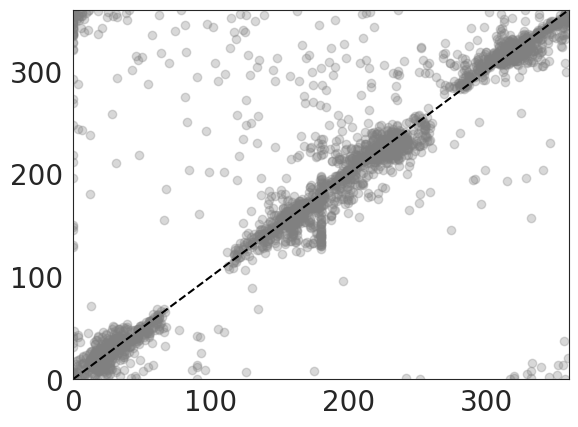

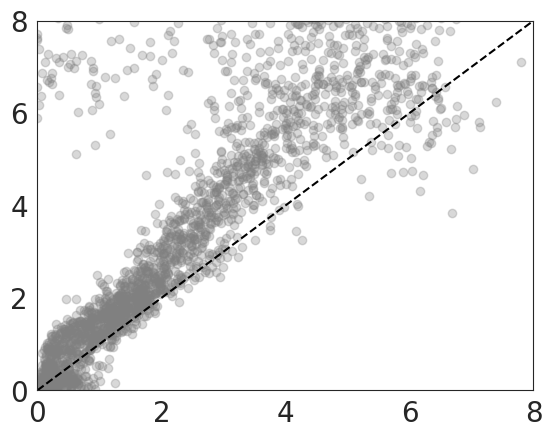

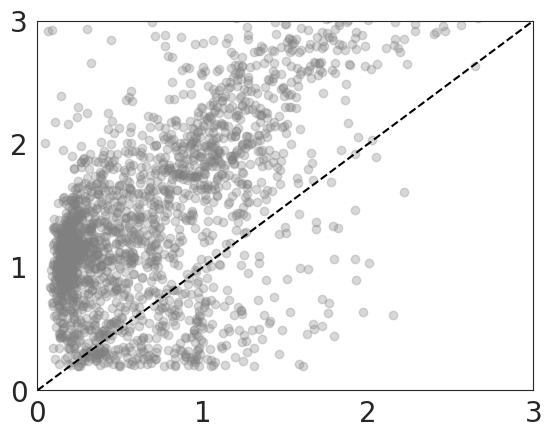

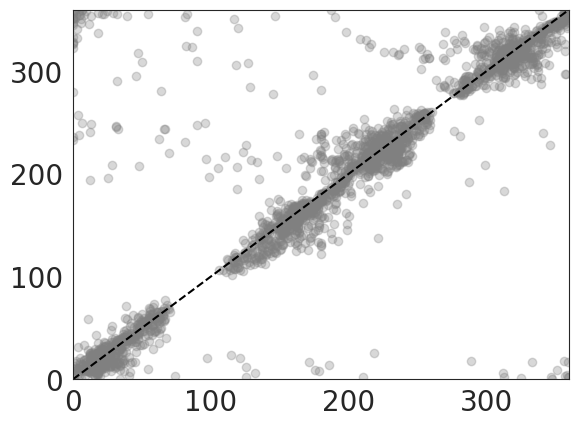

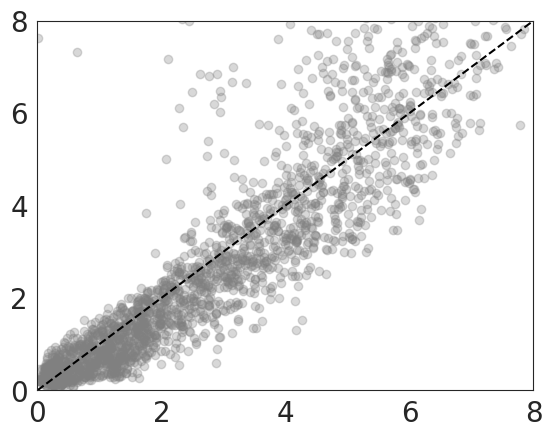

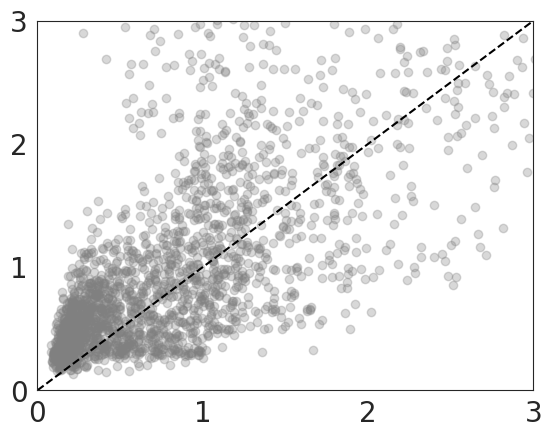

In [48]:
for dataset_name_1 in ['hcp', 'nyu', 'stanford', 'chn', 'kiwi']:
    for dataset_name_2 in ['hcp', 'nyu', 'stanford', 'chn', 'kiwi']:
        if dataset_name_1 != dataset_name_2:
            dataset_vs_dataset(dataset_name_1, dataset_name_2)